In [120]:
import pandas as pd
import ast
import argparse
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import math
import textwrap
import numpy as np

## Load data

In [2]:
base_annotation_dir = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions"

dataset_fulltext = pd.read_csv(f"{base_annotation_dir}/full_text_combined_all_annotations_metadata.csv") #_metadata
dataset_fulltext.shape

/tmp/ipykernel_1083241/402784657.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset_fulltext = pd.read_csv(f"{base_annotation_dir}/full_text_combined_all_annotations_metadata.csv") #_metadata


(371832, 21)

In [3]:
cols_to_format = ["animal_species", "animal_sex", "animal_strain", "assay_type"]

for c in cols_to_format:
    dataset_fulltext[c] = (
        dataset_fulltext[c]
        .where(dataset_fulltext[c].isna(), dataset_fulltext[c].astype(str))
        .str.replace("_", " ", regex=False)
        .str.replace("-", " ", regex=False)
        .str.replace(" & ", "&", regex=False)
        .str.title()
    )


In [4]:
dataset_fulltext["animal_sex"] = dataset_fulltext["animal_sex"].str.replace(
    "Sex Not Reported", "Not Reported", regex=False
)


In [5]:
dataset_fulltext[['sample_size']].head()

,sample_size
0,sample-size-not-reported
1,sample-size-not-reported
2,sample-size-not-reported
3,sample-size-not-reported
4,sample-size-not-reported


In [6]:
dataset_fulltext["sample_size"].unique()


array(['sample-size-not-reported', 'sample-size-present',
       'sample-size-not-performed'], dtype=object)

## Total Percentages

In [127]:
def plot_top_category_percentages(
    df,
    column,
    top_n=10,
    fillna_label="Not reported",
    wrap_width=20,
    figsize=(8, 5),
    palette="colorblind",
    save_path=None
):
    """
    Plot top-N categories as percentages (global %) in a clean, publication-style bar chart.
    """

    # --- Prepare data ---
    counts = (
        df[column]
        .fillna(fillna_label)
        .astype(str)
        .value_counts()
    )

    percentages = counts / counts.sum() * 100
    top = percentages.head(top_n).sort_values(ascending=True)

    # --- Wrap labels ---
    def wrap_label(label):
        return "\n".join(textwrap.wrap(label, width=wrap_width))

    labels = [wrap_label(l) for l in top.index]

    # --- Style ---
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=figsize)

    colors = sns.color_palette(palette, len(top))

    # --- Plot ---
    bars = plt.barh(labels, top.values, color=colors)

    # --- Add percentage labels ---
    for bar, val in zip(bars, top.values):
        plt.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center"
        )

    # --- Labels & title ---
    display_name = column.replace("_", " ").title()
    plt.xlabel("Percentage of articles (%)")
    plt.ylabel("")
    plt.title(f"Top {top_n} {display_name}", weight="bold")

    # --- Clean up ---
    sns.despine(left=True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

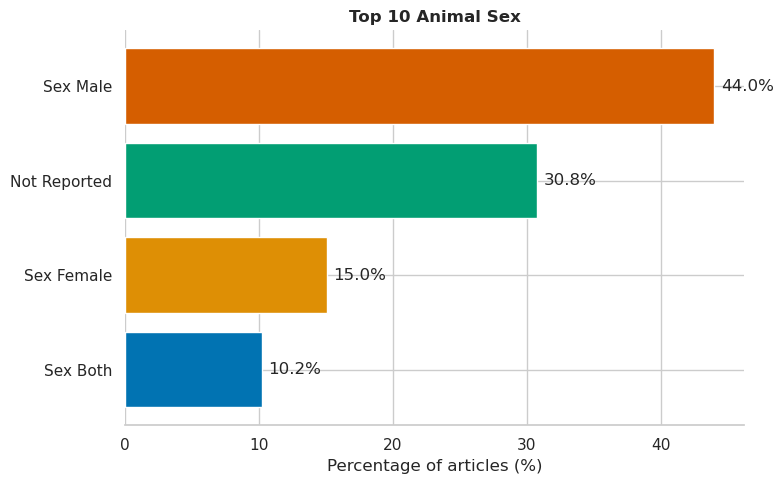

In [128]:
plot_top_category_percentages(
    dataset_fulltext,
    column="animal_sex",
    top_n=10
)

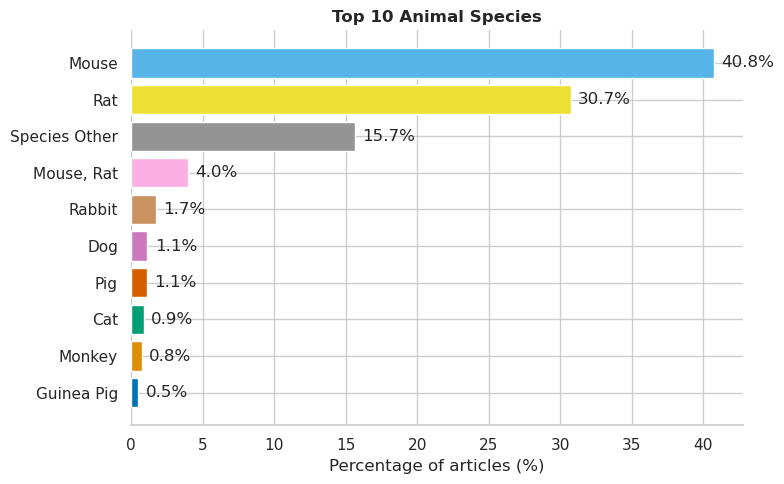

In [129]:
plot_top_category_percentages(
    dataset_fulltext,
    column="animal_species",
    top_n=10
)

In [8]:
dataset_fulltext[dataset_fulltext['PMID']=="38797312"]

,PMID,animal_sex,animal_species,rigor_blinding,rigor_randomization,rigor_welfare,assay_type,animal_strain,animal_number,sample_size,...,merged_mondo_label,merged_mondo_termid,merged_umls_label,merged_umls_termid,unique_conditions_linkbert_predictions,unique_interventions_linkbert_predictions,year,journal_name,publication_type,title
342079,38797312,Sex Male,Mouse,blinding-not-reported,randomization-present,welfare-present,"Behavioral, Histology, Molecular&Cellular",C57Bl/6,not reported,sample-size-not-reported,...,neuronitis|infectious disease with sepsis|seps...,MONDO:0004466|MONDO:1040015|-1,gibberellic acid|Ganciclovir|Gibberellins,C0061256|C0017066|C0017538,neuroinflammation|sepsis|sepsis-induced neuroi...,gibberellic acid|ga3,2024.0,European journal of pharmacology,Journal Article,Gibberellic acid targeting ZBTB16 reduces NF-κ...


In [9]:
dataset_fulltext.shape

(371832, 21)

In [10]:
def pct_reported_overall(df: pd.DataFrame, cols):
    rows = []
    n_total = len(df)

    for col in cols:
        s = df[col].astype(str).str.strip().str.lower()

        is_not_reported = (
            s.eq("not reported") |
            s.str.contains("not-reported", regex=False) |
            s.eq("nan")
        )

        n_reported = int((~is_not_reported).sum())
        pct_reported = 100.0 * n_reported / n_total if n_total else np.nan

        rows.append({
            "column": col,
            "n_total": n_total,
            "n_reported": n_reported,
            "pct_reported_overall": pct_reported,
        })

    return pd.DataFrame(rows)
cols = ["rigor_welfare", "rigor_randomization", "rigor_blinding", "sample_size"]
pct_reported_overall(dataset_fulltext, cols)


,column,n_total,n_reported,pct_reported_overall
0,rigor_welfare,371832,263847,70.958659
1,rigor_randomization,371832,127988,34.420921
2,rigor_blinding,371832,73196,19.685234
3,sample_size,371832,5956,1.601799


# Extractions

In [11]:
colorblind10 = [
    "#000000",  # black (reserved)
    "#0072B2", # ✅ blue 
    "#E69F00", # ✅ orange 
    "#009E73", # ✅ bluish green 
    "#D55E00", # ✅ vermillion 
    "#CC79A7", # ✅ reddish purple 
    "#56B4E9", # ✅ sky/light blue 
    "#F0E442", # ✅ yellow
]

def visualize_columns_nature(
    df, columns, year_col="year", top_n=10, min_year_count=25, exclude_years=None, save_path=None
):
    """
    Nature-style visualization of categorical columns:
      Left  – Top N absolute frequencies (bar chart, sorted high→low)
      Right – % of articles over time + total volume (grey dashed line)

    Color rules:
      1) "not reported" and "species-other" are always black
      2) remaining categories are colored by rank (highest -> lowest) using colorblind10 order
         (excluding black to avoid duplicates)
      3) ties are broken deterministically by label to keep rank->color stable
    """
    # ---- Style setup ----
    sns.set_theme(style="whitegrid", font_scale=1.4)
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "legend.fontsize": 18,
        "legend.title_fontsize": 18,
    })

    # --- Ensure numeric years and filtering ---
    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)].sort_values(by=year_col)

    # --- Label wrapping for display only ---
    def wrap_label(val, max_items=2):
        if isinstance(val, str) and "," in val:
            parts = [p.strip() for p in val.split(",") if p.strip()]
            if len(parts) > max_items:
                mid = len(parts) // 2
                return ", ".join(parts[:mid]) + "\n" + ", ".join(parts[mid:])
        else:
            parts = [p.strip() for p in str(val).split(" ") if p.strip()]
            if len(parts) > 3:
                mid = len(parts) // 2
                return " ".join(parts[:mid]) + "\n" + " ".join(parts[mid:])
        return str(val)

    # --- palette rules ---
    BLACK = colorblind10[0]
    RESERVED_BLACK_LABELS = {"not reported", "species-other"}
    rank_palette = colorblind10[1:]  # exclude black so it cannot be assigned twice

    # --- Figure setup ---
    n_rows = len(columns)
    fig, axes = plt.subplots(
        n_rows, 2, figsize=(20, 6 * n_rows),
        gridspec_kw={"wspace": 0.2, "hspace": 0.4}
    )
    if n_rows == 1:
        axes = [axes]

    for i, col in enumerate(columns):
        ax_bar, ax_trend = axes[i]

        # === LEFT: Top-N absolute counts (deterministic ranking) ===
        vc = df[col].dropna().astype(str).value_counts()

        # deterministic Top-N: sort by count DESC, then label ASC
        top_df = vc.reset_index()
        top_df.columns = ["label", "count"]
        top_df = top_df.sort_values(["count", "label"], ascending=[False, True]).head(top_n)

        # labels in rank order (highest -> lowest)
        ranked_labels = top_df["label"].tolist()

        # for the barplot display (we invert y-axis, so sort ascending for plotting)
        top_values = top_df.set_index("label")["count"].sort_values(ascending=True)

        # --- Build color_map with your rules ---
        color_map = {}

        # 1) reserved black labels first (if present in top_n)
        for lab in ranked_labels:
            if lab in RESERVED_BLACK_LABELS:
                color_map[lab] = BLACK

        # 2) remaining labels get rank colors in order (highest -> lowest),
        #    skipping reserved labels
        non_black_labels = [lab for lab in ranked_labels if lab not in RESERVED_BLACK_LABELS]
        if len(non_black_labels) > len(rank_palette):
            raise ValueError(
                f"Need more colors: {len(non_black_labels)} non-black categories but only "
                f"{len(rank_palette)} colors in rank_palette."
            )
        for idx, lab in enumerate(non_black_labels):
            color_map[lab] = rank_palette[idx]

        # --- BARPLOT (no seaborn deprecation warning) ---
        top_display = top_values.copy()
        top_display.index = [wrap_label(v) for v in top_display.index]

        palette_dict = {wrap_label(lab): color_map[lab] for lab in top_values.index}

        sns.barplot(
            y=top_display.index,
            x=top_display.values,
            hue=top_display.index,
            palette=palette_dict,
            ax=ax_bar,
            dodge=False,
            legend=False,
        )

        ax_bar.invert_yaxis()
        ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax_bar.set_xlabel("Number of articles", labelpad=8)
        ax_bar.set_ylabel("")

        display_col = col.replace("_"," ").title()
        if "sex" in col:
             ax_bar.set_title(f"{display_col} ", pad=12, weight="bold")
        else:
            ax_bar.set_title(f"Top {top_n} {display_col}", pad=12, weight="bold")
        sns.despine(ax=ax_bar, left=True)

        # === RIGHT: % over time + total ===
        trend_counts = df.groupby([year_col, col]).size().unstack(fill_value=0)
        
        # keep only top-N categories (for plotting), but normalize vs ALL articles/year
        ordered_cols = [lab for lab in ranked_labels if lab in trend_counts.columns]
        trend_counts_top = trend_counts[ordered_cols]
        
        total_per_year = df.groupby(year_col).size()
        
        # normalize per articles/year (correct)
        trend_pct = trend_counts_top.div(total_per_year, axis=0) * 100
        trend_pct = trend_pct.sort_index()
        

        total_per_year = df.groupby(year_col).size()

        for lab in ordered_cols:
            ax_trend.plot(
                trend_pct.index,
                trend_pct[lab],
                label=wrap_label(lab),
                color=color_map[lab],
                linewidth=2.5,
            )

        ax_twin = ax_trend.twinx()
        total_per_year.plot(
            ax=ax_twin,
            color="#666666",
            linestyle="--",
            linewidth=2,
            alpha=0.7,
            label="Total articles",
        )

        ax_trend.set_xlabel("Publication year", labelpad=8)
        ax_trend.set_ylabel("Share of articles (%)")
        ax_twin.set_ylabel("Total articles", labelpad=8)
        ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax_twin.grid(False)
        ax_trend.set_title(f"{display_col} Over Time", pad=12, weight="bold")
        sns.despine(ax=ax_trend, left=False, right=False)

        handles, labels = ax_trend.get_legend_handles_labels()
        handles2, labels2 = ax_twin.get_legend_handles_labels()
        ax_trend.legend(
            handles + handles2,
            labels + labels2,
            bbox_to_anchor=(1.22, 1),
            loc="upper left",
            frameon=False,
            title=f"{display_col} (top {top_n})",
        )

    plt.subplots_adjust(left=0.08, right=0.78, top=0.95, bottom=0.07)
    fig.patch.set_facecolor("white")
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


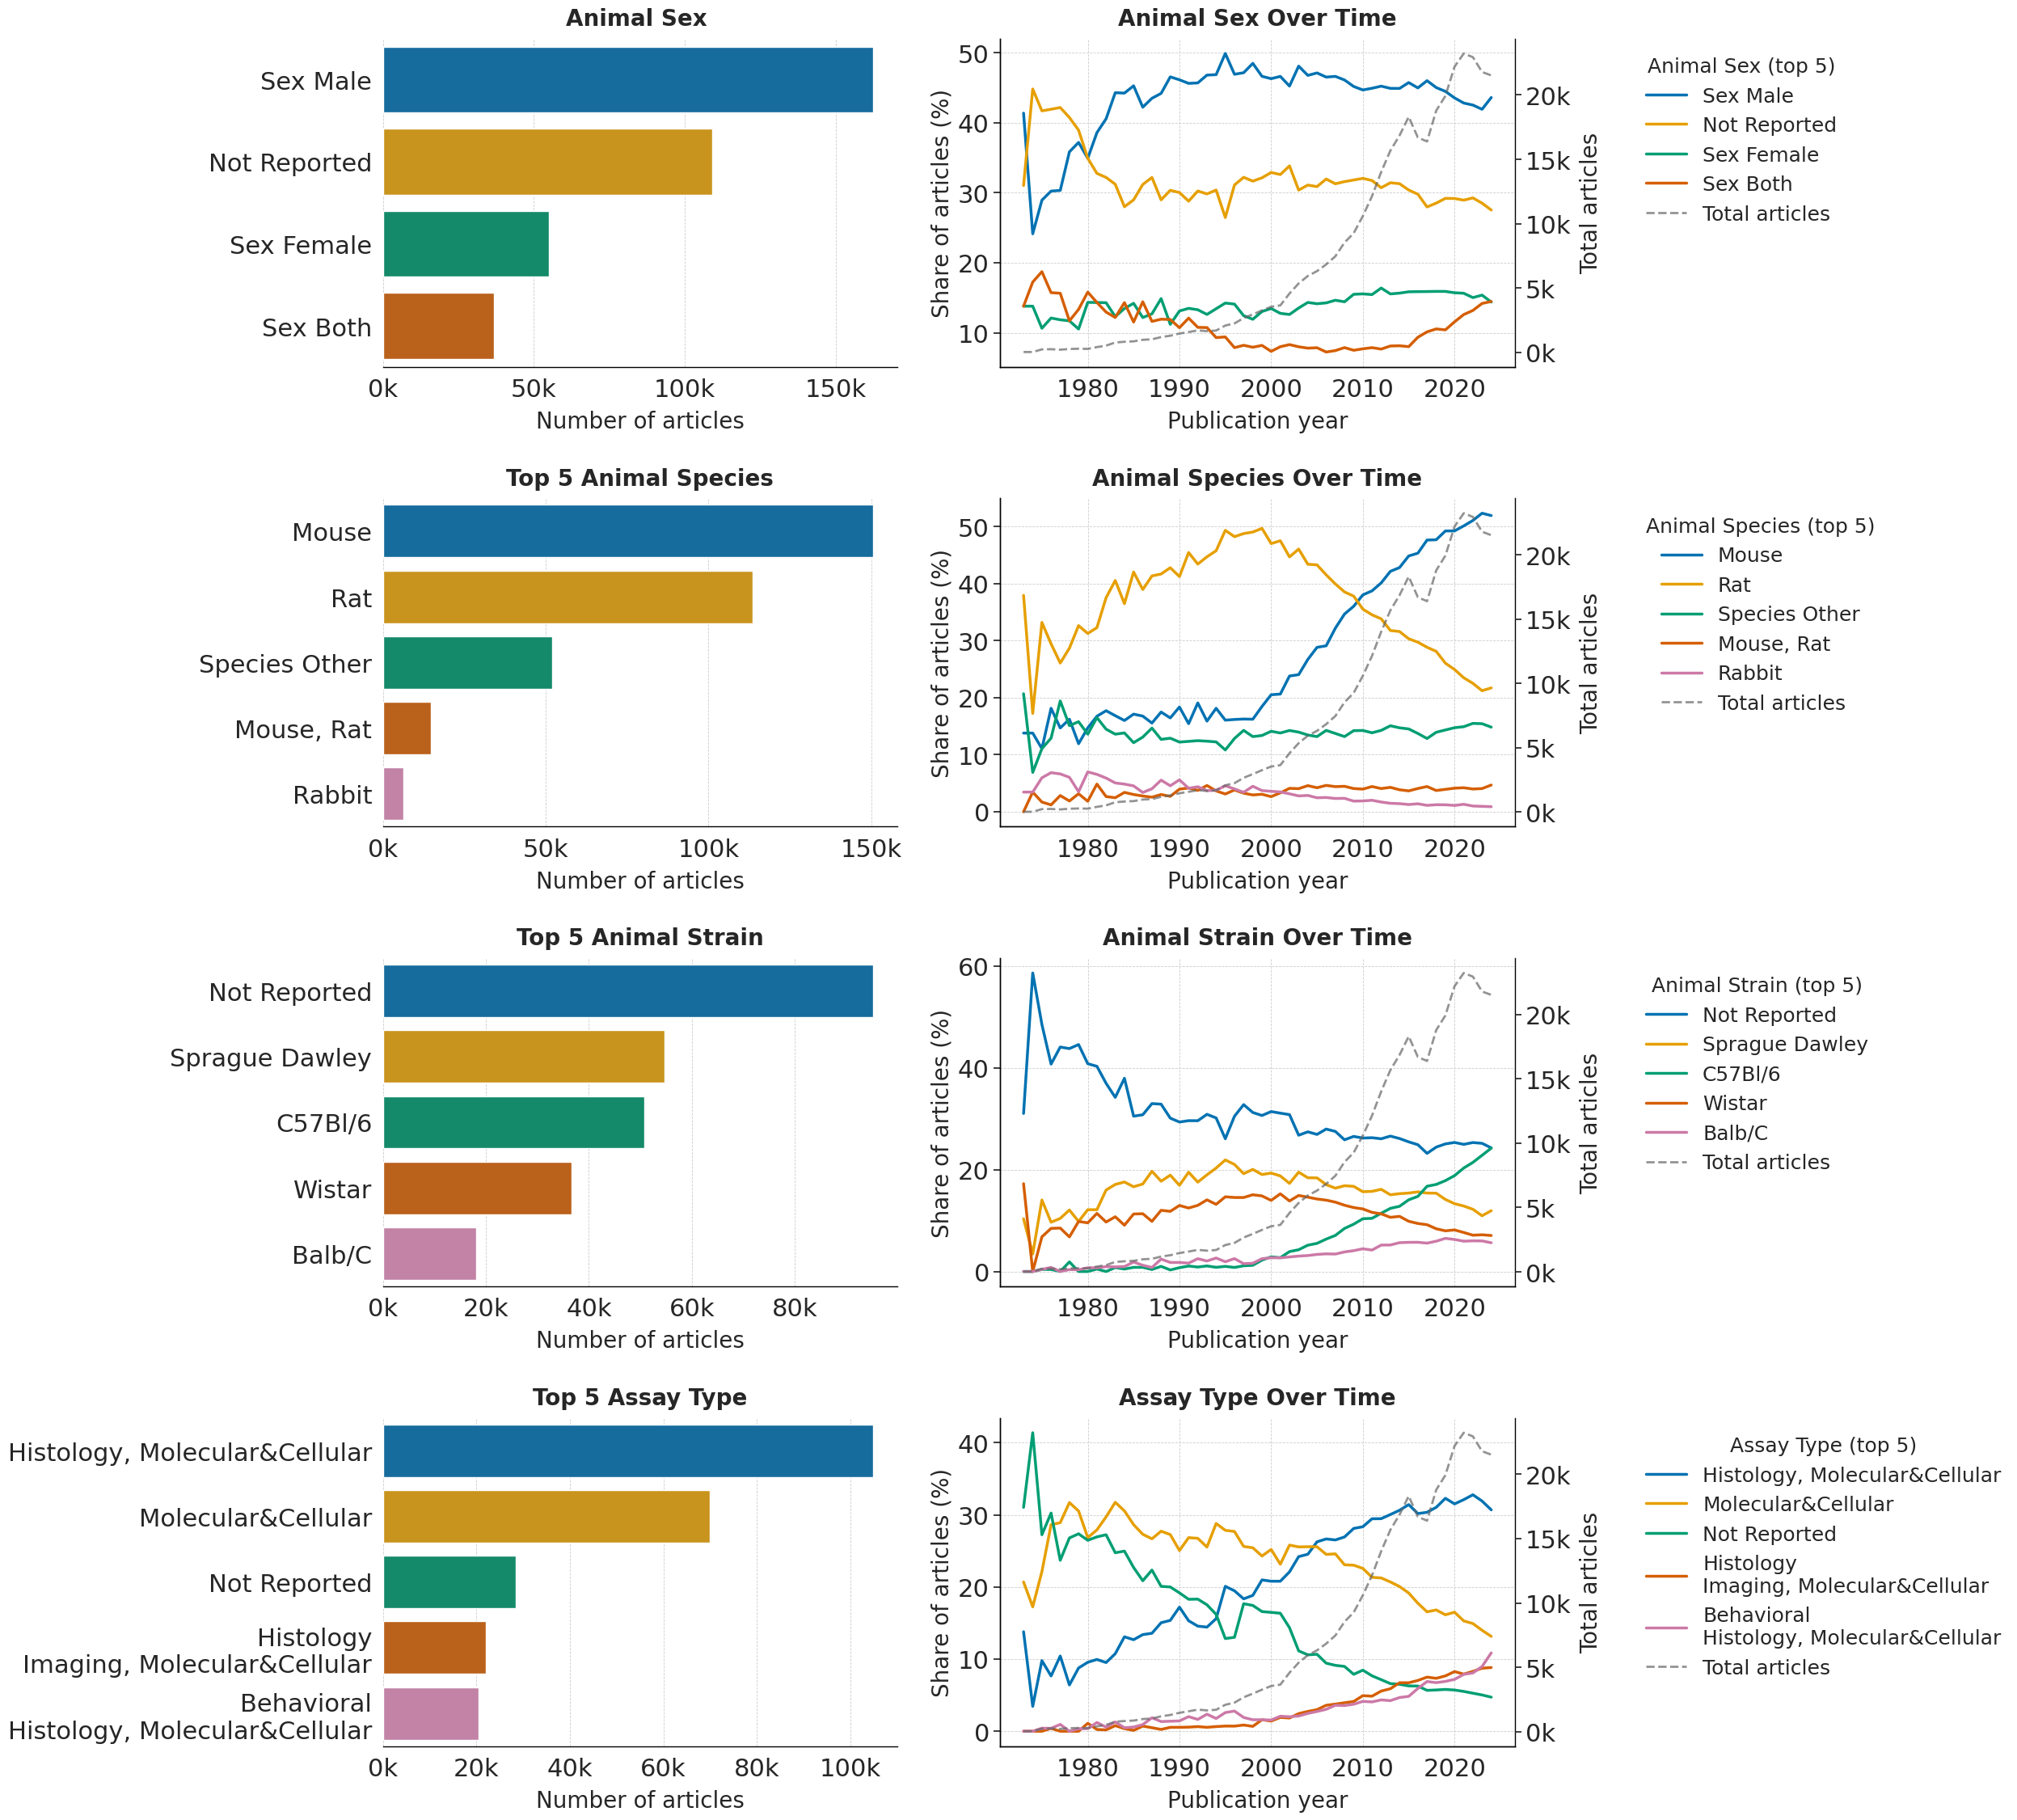

In [12]:
cols_to_plot = ['animal_sex', 'animal_species', 'animal_strain', 'assay_type']

visualize_columns_nature(
    dataset_fulltext,
    cols_to_plot,
    exclude_years=[2025],
    top_n=5,
    save_path = "viz/animal_studies_metadata.pdf"
)


## characteristics + rigor

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Your palette (black reserved)
colorblind10 = [
    "#000000",  # black (reserved)
    "#0072B2", # ✅ blue 
    "#E69F00", # ✅ orange 
    "#009E73", # ✅ bluish green 
    "#D55E00", # ✅ vermillion 
    "#CC79A7", # ✅ reddish purple 
    "#56B4E9", # ✅ sky/light blue 
    "#F0E442", # ✅ yellow
]


def _apply_nature_style():
    sns.set_theme(style="whitegrid", font_scale=1.4)
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "legend.fontsize": 18,
        "legend.title_fontsize": 18,
    })


def _wrap_label(val, max_items=2):
    val = str(val)
    if "," in val:
        parts = [p.strip() for p in val.split(",") if p.strip()]
        if len(parts) > max_items:
            mid = len(parts) // 2
            return ", ".join(parts[:mid]) + "\n" + ", ".join(parts[mid:])
    else:
        parts = [p.strip() for p in val.split(" ") if p.strip()]
        if len(parts) > 3:
            mid = len(parts) // 2
            return " ".join(parts[:mid]) + "\n" + " ".join(parts[mid:])
    return val

def display_label(val: str) -> str:
    # strip the "-present" suffix only for display
    return val.replace("-present", "").title()
    
def plot_selected_value_trends_row(
    df: pd.DataFrame,
    *,
    ax_bar,
    ax_trend,
    columns,
    values,
    year_col="year",
    min_year_count=25,
    exclude_years=None,
    title_left="Total frequency",
    title_right="Trends of selected categories over time",
    show_legend=False
):
    """
    Plot a single extra row:
      LEFT  – total counts for the selected (column,value) pairs
      RIGHT – % over time + total volume

    Does NOT create a new figure; draws into provided axes.
    """
    assert len(columns) == len(values), "`columns` and `values` must have the same length."

    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)].sort_values(by=year_col)

    total_per_year = df.groupby(year_col).size()

    # Compute totals for each selected (col,val)
    labels = []
    totals = []
    for col, val in zip(columns, values):
        labels.append(display_label(str(val)))
        totals.append(int((df[col].astype(str) == str(val)).sum()))

    totals_s = pd.Series(totals, index=labels)

    # Deterministic order: highest->lowest, tie-break by label
    totals_df = totals_s.reset_index()
    totals_df.columns = ["label", "count"]
    totals_df = totals_df.sort_values(["count", "label"], ascending=[False, True])

    ranked_labels = totals_df["label"].tolist()  # high->low
    totals_for_bar = totals_df.set_index("label")["count"].sort_values(ascending=True)

    # Rank palette excluding black (so black stays reserved)
    rank_palette = colorblind10[1:]

    if len(ranked_labels) > len(rank_palette):
        raise ValueError(
            f"Need more colors: {len(ranked_labels)} selected series but only {len(rank_palette)} colors."
        )

    color_map = {lab: rank_palette[i] for i, lab in enumerate(ranked_labels)}

    # LEFT: bar
    palette_dict = {lab: color_map[lab] for lab in totals_for_bar.index}
    sns.barplot(
        y=totals_for_bar.index,
        x=totals_for_bar.values,
        hue=totals_for_bar.index,
        palette=palette_dict,
        ax=ax_bar,
        dodge=False,
        legend=False,
    )
    ax_bar.invert_yaxis()
    ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    ax_bar.set_xlabel("Number of articles", labelpad=8)
    ax_bar.set_ylabel("")
    ax_bar.set_title(title_left, pad=12, weight="bold")
    ax_bar.tick_params(axis="both", labelsize=20)
    sns.despine(ax=ax_bar, left=True)

    # RIGHT: trends (%)
    for col, val in zip(columns, values):
        val = str(val)
        subset = df[df[col].astype(str) == val]
        yearly_counts = subset.groupby(year_col).size()
        share = (yearly_counts / total_per_year * 100).reindex(total_per_year.index).fillna(0)

        disp = display_label(val)
        ax_trend.plot(
            share.index,
            share.values,
            label=disp,
            color=color_map[disp],
            linewidth=2.5,
        )

    ax_twin = ax_trend.twinx()
    total_per_year.plot(
        ax=ax_twin,
        color="#666666",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
        label="All articles",
    )

    ax_trend.set_xlabel("Publication year", labelpad=8)
    ax_trend.set_ylabel("Share of articles (%)")
    ax_twin.set_ylabel("All articles", labelpad=8)
    ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    ax_twin.grid(False)
    ax_trend.set_title(title_right, pad=12, weight="bold")
    sns.despine(ax=ax_trend, left=False, right=False)
    ax_trend.tick_params(axis="both", labelsize=20)
    if show_legend:
        h1, l1 = ax_trend.get_legend_handles_labels()
        h2, l2 = ax_twin.get_legend_handles_labels()
        ax_trend.legend(
            h1 + h2,
            l1 + l2,
            bbox_to_anchor=(1.22, 1),
            loc="upper left",
            frameon=False,
            title="Rigor Indicator",
            fontsize=22,          # ⬅ legend label size
            title_fontsize=24,    # ⬅ legend title size
        )
    else:
            ax_twin.legend(
                loc="upper left",
                frameon=True,
                fontsize=20,
            )

def add_panel_labels_left_column(axes, start_letter="A", x_points=-35, y_points=10):
    """
    Put A, B, C... just outside the top-left of each left-column axis.
    Offsets are in points, so they look consistent across rows.
    """
    for i, ax in enumerate(axes):
        label = chr(ord(start_letter) + i)
        ax.annotate(
            label,
            xy=(0, 1), xycoords="axes fraction",          # top-left corner of axes
            xytext=(x_points, y_points), textcoords="offset points",  # shift outside
            ha="right", va="bottom",
            fontsize=26, fontweight="bold",
            clip_on=False,
        )

def visualize_columns_nature_composite(
    df,
    columns,
    *,
    year_col="year",
    top_n=10,
    min_year_count=25,
    exclude_years=None,
    save_path=None,
    # extra row
    extra_row_columns=None,
    extra_row_values=None,
    extra_row_title="Selected trends",
    show_legend=False
):
    """
    Multi-row composite:
      rows 0..len(columns)-1 : per-column (bar + trend)
      last row (optional)    : selected-trends (bar + trend)
    """
    _apply_nature_style()

    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)].sort_values(by=year_col)

    add_extra = extra_row_columns is not None and extra_row_values is not None
    n_rows = len(columns) + (1 if add_extra else 0)

    fig, axes = plt.subplots(
        n_rows, 2,
        figsize=(20, 6 * n_rows),
        gridspec_kw={"wspace": 0.2, "hspace": 0.4},
        squeeze=False,
    )

    # palette rules for the per-column plots
    BLACK = colorblind10[0]
    RESERVED_BLACK_LABELS = {"Not Reported", "Species Other"}
    rank_palette = colorblind10[1:]  # exclude black

    for i, col in enumerate(columns):
        ax_bar = axes[i, 0]
        ax_trend = axes[i, 1]

        # === Top-N deterministic ranking ===
        vc = df[col].dropna().astype(str).value_counts()
        top_df = vc.reset_index()
        top_df.columns = ["label", "count"]
        top_df = top_df.sort_values(["count", "label"], ascending=[False, True]).head(top_n)

        ranked_labels = top_df["label"].tolist()        # highest -> lowest
        top_values = top_df.set_index("label")["count"].sort_values(ascending=True)  # for bar display

        # build color_map:
        color_map = {}

        # reserved black labels
        for lab in ranked_labels:
            if lab in RESERVED_BLACK_LABELS:
                color_map[lab] = BLACK

        non_black_labels = [lab for lab in ranked_labels if lab not in RESERVED_BLACK_LABELS]
        if len(non_black_labels) > len(rank_palette):
            raise ValueError(
                f"Need more colors: {len(non_black_labels)} non-black categories but only {len(rank_palette)} colors."
            )
        for idx, lab in enumerate(non_black_labels):
            color_map[lab] = rank_palette[idx]

        # --- LEFT: barplot ---
        top_display = top_values.copy()
        top_display.index = [_wrap_label(v) for v in top_display.index]
        palette_dict = {_wrap_label(lab): color_map[lab] for lab in top_values.index}

        sns.barplot(
            y=top_display.index,
            x=top_display.values,
            hue=top_display.index,
            palette=palette_dict,
            ax=ax_bar,
            dodge=False,
            legend=False,
        )

        ax_bar.invert_yaxis()
        ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax_bar.set_xlabel("Number of articles", labelpad=8)
        ax_bar.set_ylabel("")
        display_col = col.replace("_"," ").title()
        if "sex" in col:
            ax_bar.set_title(f"{display_col} ", pad=12, weight="bold")
        else:
            ax_bar.set_title(f"Top {top_n} {display_col}", pad=12, weight="bold")
        sns.despine(ax=ax_bar, left=True)
        ax_bar.tick_params(axis="both", labelsize=20)
        # collect left-column axes
        left_axes = [axes[i, 0] for i in range(n_rows)]
        add_panel_labels_left_column(left_axes, start_letter="A", x_points=-35, y_points=10)


        # --- RIGHT: % over time ---
        subset = df[df[col].astype(str).isin(top_values.index)]
        trend_data = subset.groupby([year_col, col]).size().unstack(fill_value=0)
        
        ordered_cols = [lab for lab in ranked_labels if lab in trend_data.columns]
        trend_data = trend_data[ordered_cols].sort_index()
        
        total_per_year = df.groupby(year_col).size().sort_index()
        
        trend_pct = trend_data.div(total_per_year, axis=0) * 100

        for lab in ordered_cols:
            ax_trend.plot(
                trend_pct.index,
                trend_pct[lab],
                label=_wrap_label(lab),
                color=color_map[lab],
                linewidth=2.5,
            )

        ax_twin = ax_trend.twinx()
        total_per_year.plot(
            ax=ax_twin,
            color="#666666",
            linestyle="--",
            linewidth=2,
            alpha=0.7,
            label="All articles",
        )

        ax_trend.set_xlabel("Publication year", labelpad=8)
        ax_trend.set_ylabel("Share of articles (%)")
        ax_twin.set_ylabel("All articles", labelpad=8)
        ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax_twin.grid(False)
        ax_trend.set_title(f"{display_col} Over Time", pad=12, weight="bold")
        sns.despine(ax=ax_trend, left=False, right=False)
        ax_trend.set_ylim(0, 100)
        ax_trend.tick_params(axis="both", labelsize=20)
        if show_legend:
            h1, l1 = ax_trend.get_legend_handles_labels()
            h2, l2 = ax_twin.get_legend_handles_labels()
            ax_trend.legend(
                h1 + h2,
                l1 + l2,
                bbox_to_anchor=(1.22, 1),
                loc="upper left",
                frameon=False,
                title=f"{display_col}",
                fontsize=22,          # ⬅ legend label size
                title_fontsize=24,    # ⬅ legend title size
            )
        else:
            ax_twin.legend(
                loc="upper left",
                frameon=True,
                fontsize=20,
            )

    # ---- optional extra row at the bottom ----
    if add_extra:
        ax_bar = axes[-1, 0]
        ax_trend = axes[-1, 1]
        plot_selected_value_trends_row(
            df,
            ax_bar=ax_bar,
            ax_trend=ax_trend,
            columns=extra_row_columns,
            values=extra_row_values,
            year_col=year_col,
            min_year_count=min_year_count,
            exclude_years=exclude_years,
            title_left="Presence Of Rigor Indicators",
            title_right=extra_row_title,
        )

    plt.subplots_adjust(left=0.08, right=0.78, top=0.95, bottom=0.07)
    fig.patch.set_facecolor("white")


    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()


In [14]:
path = "elife-13615-supp1.xlsx" # FROM https://pubmed.ncbi.nlm.nih.gov/26939790/

df_ref_study = pd.read_excel(path)

ref_pmids = (
    df_ref_study["PMID"]
    .dropna()
    .astype(str)   # PMIDs should be integers
    .tolist()
)
len(ref_pmids)

15311

In [15]:
dataset_fulltext["PMID"] = dataset_fulltext["PMID"].astype(str).str.strip()

dataset_fulltext_filtered = dataset_fulltext[dataset_fulltext["PMID"].isin(ref_pmids)]
dataset_fulltext_filtered.shape

(2394, 21)

In [16]:
dataset_fulltext_filtered["animal_sex"].value_counts(dropna=False)


animal_sex
Sex Male        1033
Sex Female       528
Not Reported     528
Sex Both         305
Name: count, dtype: int64

In [17]:
dataset_fulltext_mouse_only = dataset_fulltext[dataset_fulltext['animal_species'].str.contains("Mouse")]
dataset_fulltext_mouse_only.shape

(171516, 21)

In [18]:
dataset_fulltext_disease = dataset_fulltext[
    dataset_fulltext["merged_mondo_label"].astype(str).str.contains("depression", case=False, na=False)
]
dataset_fulltext_disease.shape

(1129, 21)

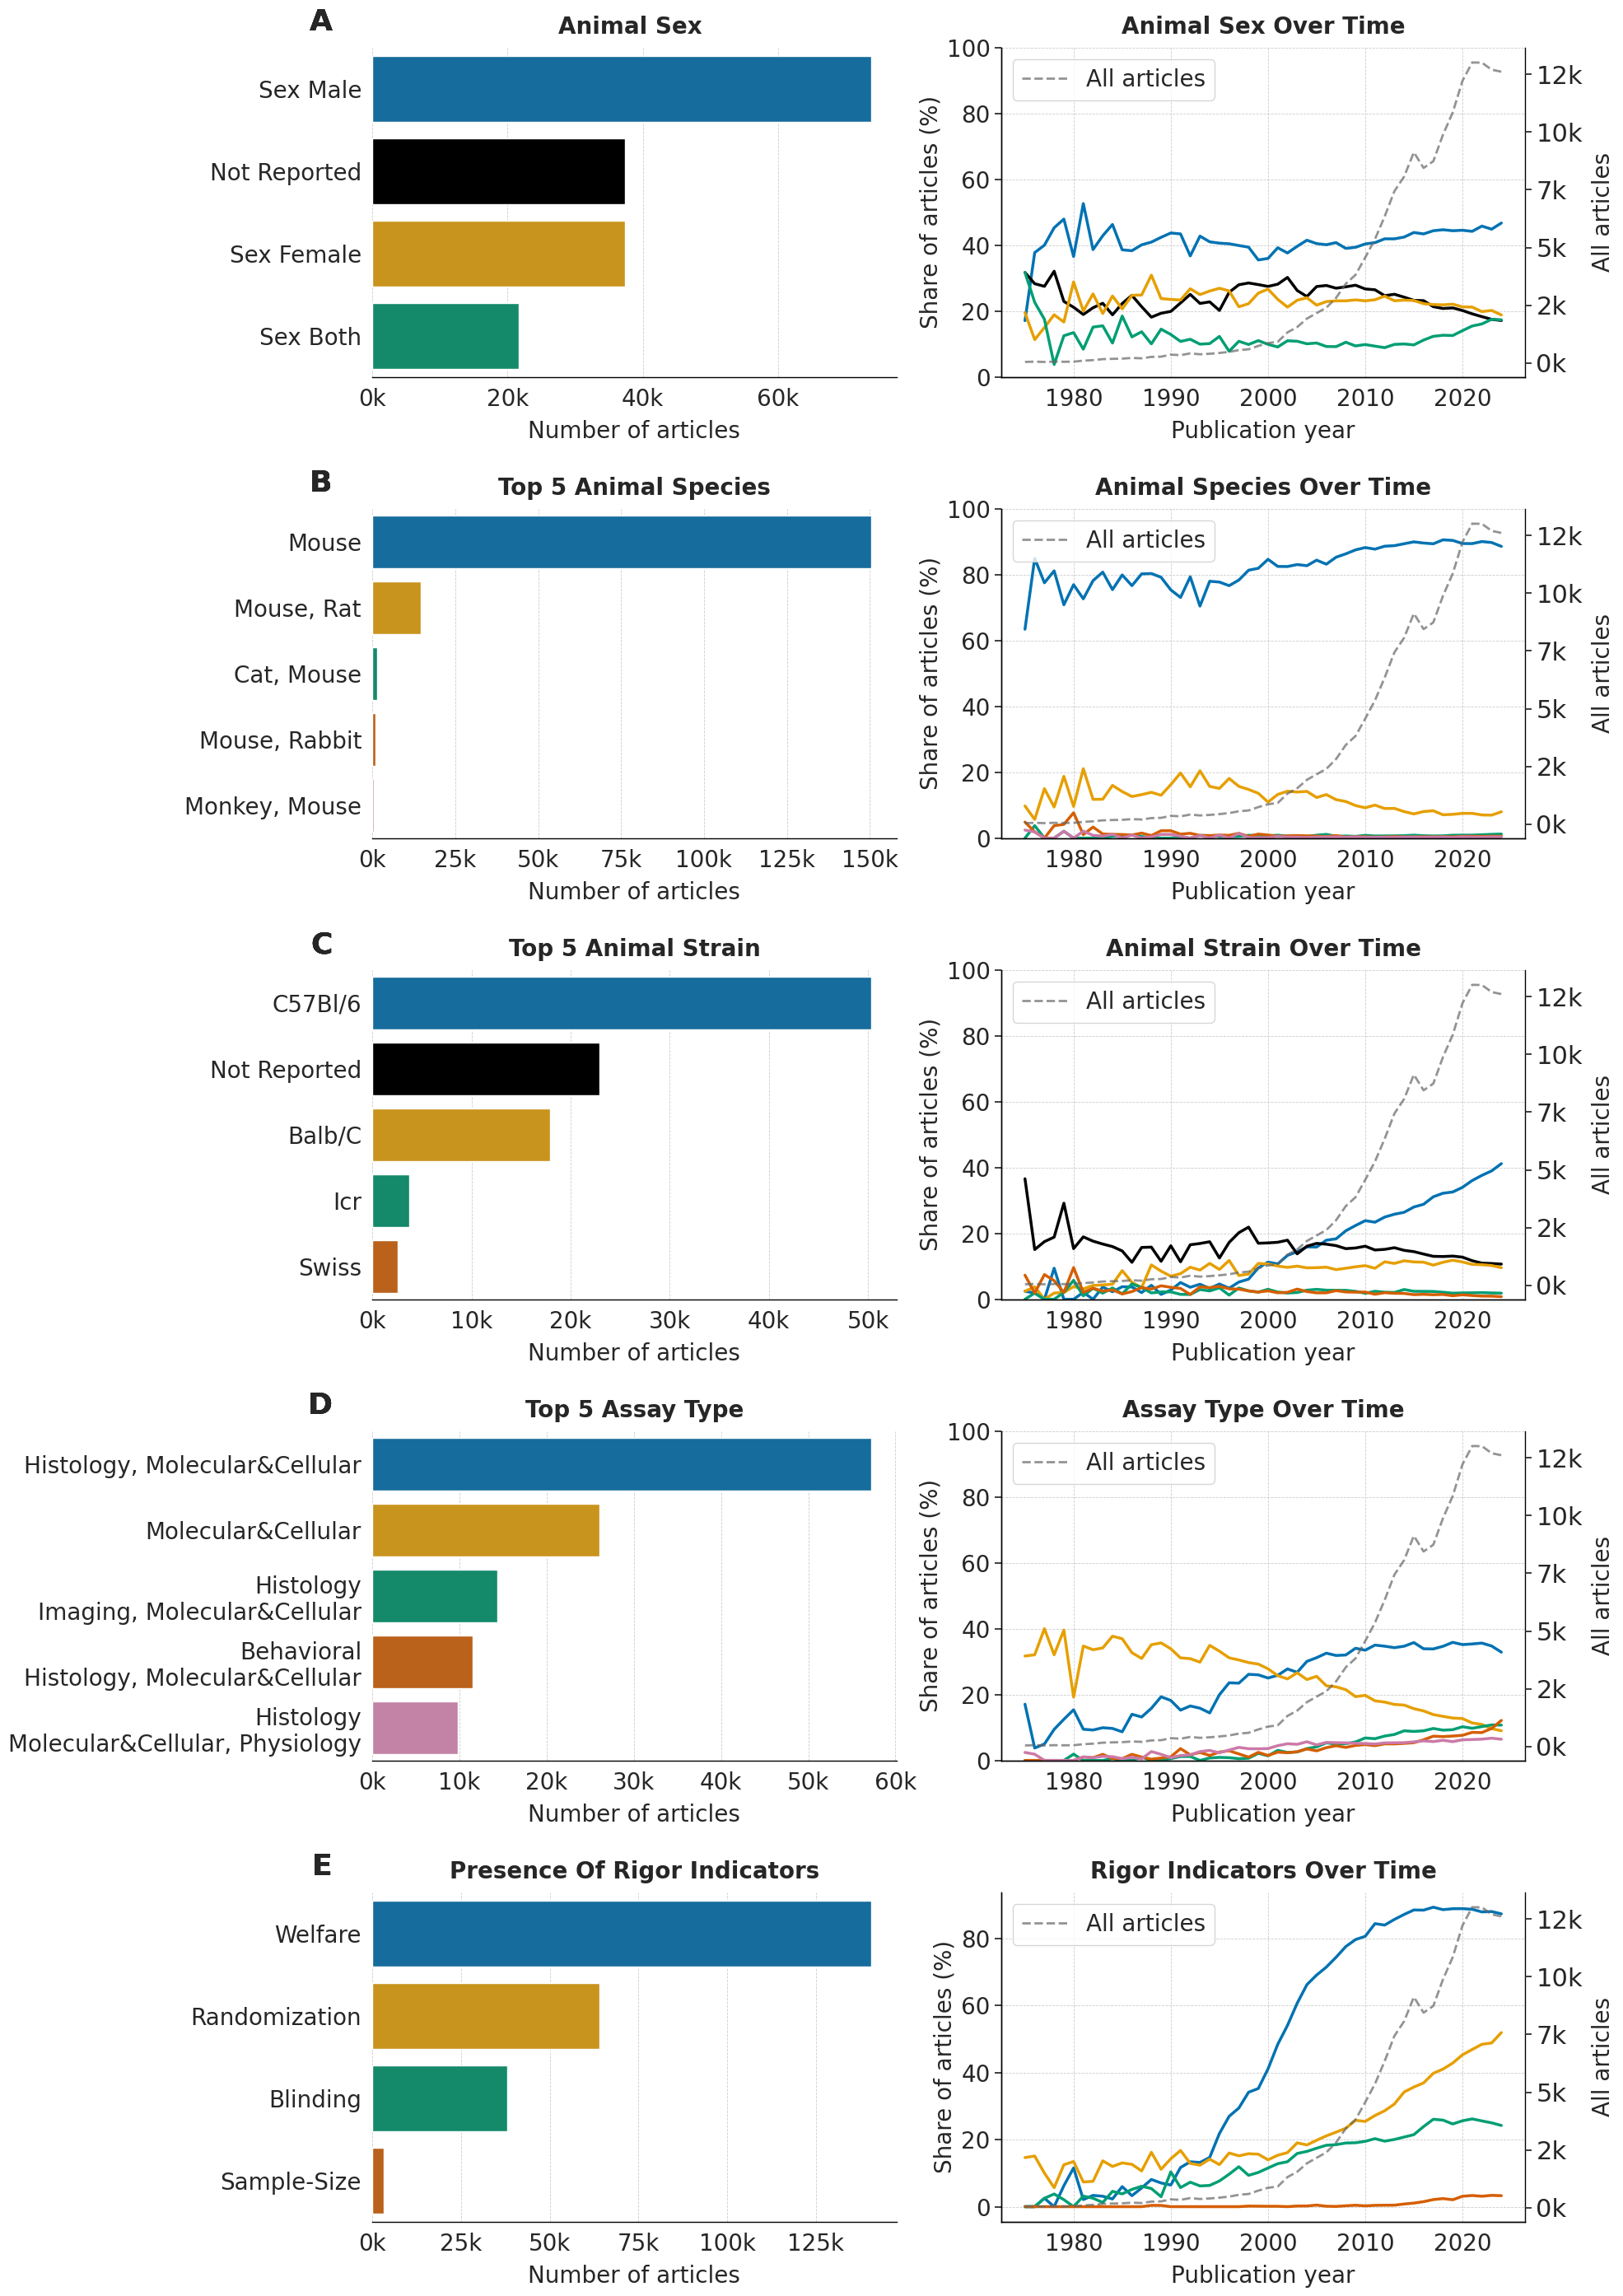

In [19]:
cols_to_plot = ["rigor_welfare", "rigor_randomization", "rigor_blinding", "sample_size"]

visualize_columns_nature_composite(
    dataset_fulltext_mouse_only,
    columns=['animal_sex', 'animal_species', 'animal_strain', 'assay_type'],
    top_n=5,
    exclude_years=[2025],
    min_year_count=25,
    save_path="viz/composite_with_rigor_row.pdf",
    extra_row_columns=cols_to_plot,
    extra_row_values=[
        "welfare-present",
        "randomization-present",
        "blinding-present",
        "sample-size-present",
    ],
    extra_row_title="Rigor Indicators Over Time",
)

## 3 columns

In [142]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Your palette (black reserved)
colorblind10 = [
    "#000000",  # black (reserved)
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # bluish green
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#56B4E9",  # sky/light blue
    "#F0E442",  # yellow
]


def _apply_nature_style():
    sns.set_theme(style="whitegrid", font_scale=1.4)
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 20,
        "axes.titlesize": 20,
        "xtick.labelsize": 22,
        "ytick.labelsize": 22,
        "legend.fontsize": 18,
        "legend.title_fontsize": 18,
    })


def _wrap_label(val, max_items=2):
    val = str(val)
    if "," in val:
        parts = [p.strip() for p in val.split(",") if p.strip()]
        if len(parts) > max_items:
            mid = len(parts) // 2
            return ", ".join(parts[:mid]) + "\n" + ", ".join(parts[mid:])
    else:
        parts = [p.strip() for p in val.split(" ") if p.strip()]
        if len(parts) > 3:
            mid = len(parts) // 2
            return " ".join(parts[:mid]) + "\n" + " ".join(parts[mid:])
    return val


def display_label(val: str) -> str:
    s = str(val).replace("-present", "").strip()
    s = s.replace("–", "-").replace("—", "-")

    s_norm = s.lower()

    if s_norm in {"usa", "uk"}:
        return s.upper()
    elif s_norm == "sample-size":
        return "Sample Size Calculation"
    else:
        return s.title()


def add_panel_labels_left_column(axes, start_letter="A", x_points=-35, y_points=10):
    """
    Put A, B, C... just outside the top-left of each left-column axis.
    Offsets are in points, so they look consistent across rows.
    """
    for i, ax in enumerate(axes):
        label = chr(ord(start_letter) + i)
        ax.annotate(
            label,
            xy=(0, 1), xycoords="axes fraction",
            xytext=(x_points, y_points), textcoords="offset points",
            ha="right", va="bottom",
            fontsize=26, fontweight="bold",
            clip_on=False,
        )


def plot_selected_value_trends_row_3col(
    df: pd.DataFrame,
    *,
    ax_bar,
    ax_trend_cnt,   # CENTER = totals over time
    ax_trend_pct,   # RIGHT  = proportions over time
    columns,
    values,
    year_col="year",
    min_year_count=25,
    exclude_years=None,
    title_left="Total frequency",
    title_mid="Trends (counts/year)",
    title_right="Trends (% of articles/year)",
    show_legend=False,
):
    """
    Extra row:
      LEFT   – total counts for selected (column,value) pairs
      CENTER – counts over time (absolute per year)
      RIGHT  – % over time (normalized per articles/year) + total volume (twin axis)
    """
    assert len(columns) == len(values), "`columns` and `values` must have the same length."

    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)].sort_values(by=year_col)

    # Article-level totals (safer)
    total_per_year = df.groupby(year_col)["PMID"].nunique().sort_index()

    # totals per selected pair
    labels = []
    totals = []

    for col, val in zip(columns, values):
        #wrap_label(v) for v in top_values.index
        labels.append(_wrap_label(display_label(val),width=32))
        totals.append(int((df[col].astype(str) == str(val)).sum()))

    totals_df = pd.DataFrame({"label": labels, "count": totals}).sort_values(
        ["count", "label"], ascending=[False, True]
    )
    print(totals_df)

    ranked_labels = totals_df["label"].tolist()  # high->low
    totals_for_bar = totals_df.set_index("label")["count"].sort_values(ascending=True)

    rank_palette = colorblind10[1:]
    if len(ranked_labels) > len(rank_palette):
        raise ValueError(f"Need more colors: {len(ranked_labels)} series but only {len(rank_palette)} colors.")

    color_map = {lab: rank_palette[i] for i, lab in enumerate(ranked_labels)}

    # LEFT: bar
    sns.barplot(
        y=totals_for_bar.index,
        x=totals_for_bar.values,
        hue=totals_for_bar.index,
        palette={lab: color_map[lab] for lab in totals_for_bar.index},
        ax=ax_bar,
        dodge=False,
        legend=False,
    )
    ax_bar.invert_yaxis()
    ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    ax_bar.set_xlabel("Number of articles", labelpad=8)
    ax_bar.set_ylabel("")
    ax_bar.set_title(title_left, pad=12, weight="bold")
    sns.despine(ax=ax_bar, left=True)

    # CENTER: counts/year
    for col, val in zip(columns, values):
        raw = str(val)
        #disp = display_label(raw)
        disp = _wrap_label(display_label(raw),width=32)
        subset = df[df[col].astype(str) == raw]
        yearly_counts = subset.groupby(year_col)["PMID"].nunique().sort_index()
        yearly_counts = yearly_counts.reindex(total_per_year.index, fill_value=0)

        ax_trend_cnt.plot(
            yearly_counts.index,
            yearly_counts.values,
            label=disp,
            color=color_map[disp],
            linewidth=2.5,
        )

    ax_trend_cnt.set_xlabel("Publication year", labelpad=8)
    ax_trend_cnt.set_ylabel("Number of articles")
    ax_trend_cnt.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    ax_trend_cnt.set_title(title_mid, pad=12, weight="bold")
    sns.despine(ax=ax_trend_cnt, left=False, right=False)

    # RIGHT: %/year (normalized per articles/year)
    for col, val in zip(columns, values):
        raw = str(val)
        #disp = display_label(raw)
        disp = _wrap_label(display_label(raw),width=32)
        subset = df[df[col].astype(str) == raw]
        yearly_counts = subset.groupby(year_col)["PMID"].nunique().sort_index()
        share = (yearly_counts.reindex(total_per_year.index, fill_value=0) / total_per_year) * 100

        ax_trend_pct.plot(
            share.index, share.values,
            label=disp,
            color=color_map[disp],
            linewidth=2.5,
        )

    ax_trend_pct.set_ylim(0, 100)
    ax_trend_pct.set_xlabel("Publication year", labelpad=8)
    ax_trend_pct.set_ylabel("Share of articles (%)")
    ax_trend_pct.set_title(title_right, pad=12, weight="bold")
    sns.despine(ax=ax_trend_pct, left=False, right=False)

    if show_legend:
        h1, l1 = ax_trend_pct.get_legend_handles_labels()
        h2, l2 = ax_pct_twin.get_legend_handles_labels()
        ax_trend_pct.legend(
            h1 + h2,
            l1 + l2,
            bbox_to_anchor=(1.25, 1),
            loc="upper left",
            frameon=False,
            title="Selected series",
        )
    #else:
     #   ax_pct_twin.legend(loc="upper left", frameon=True)


def _wrap_label(text, width=22):
    s = str(text).strip()

    # If it's a disease<>drug pair, force exactly two rows
    if "<>" in s:
        left, right = s.split("<>", 1)
        left = left.strip()
        right = right.strip()

        # Optional: wrap each side if still long
        left_wrapped  = "\n".join(textwrap.wrap(left,  width=width)) or left
        right_wrapped = "\n".join(textwrap.wrap(right, width=width)) or right

        # Two-line format
        return f"{left_wrapped}\n{right_wrapped}"

    # Otherwise: normal wrapping
    return "\n".join(textwrap.wrap(s, width=width)) if s else s
    

def visualize_columns_nature_composite_3col(
    df: pd.DataFrame,
    columns,
    *,
    year_col="year",
    top_n=10,
    min_year_count=25,
    exclude_years=None,
    save_path=None,
    # extra row (existing)
    extra_row_columns=None,
    extra_row_values=None,
    extra_row_title="Selected trends",
    # NEW: final row from pairs_df (no year needed)
    pairs_df=None,
    add_pairs_row=False,
    pairs_top_n=10,
    pairs_disease_col="merged_mondo_label",
    pairs_drug_col="merged_umls_label",
    pairs_pair_col="disease<>drug",
    show_legend=False,
):
    """
    3-column composite per row:
      Col 1: total counts (bar)
      Col 2: totals over time (counts/year)
      Col 3: proportions over time (%/year)

    Optional extra bottom row for selected (column,value) pairs.

    Optional final bottom row (3 bars) from pairs_df (NO year needed):
      Col 1: top diseases
      Col 2: top drugs
      Col 3: top disease<>drug pairs
    """
    _apply_nature_style()

    # ----------------------------
    # helper: single-color Top-N bar (final pairs row only)
    # ----------------------------
    def _topn_bar_single(ax, series, title, top_n=10):
        vc = series.dropna().astype(str).value_counts()
        top_df = vc.reset_index()
        top_df.columns = ["label", "count"]
        top_df = (
            top_df.sort_values(["count", "label"], ascending=[False, True])
                  .head(top_n)
                  .sort_values("count", ascending=True)
        )

        y = top_df["label"].tolist()
        if "_wrap_label" in globals():
            y = [_wrap_label(v) for v in y]

        sns.barplot(
            y=y,
            x=top_df["count"].values,
            ax=ax,
            color="#595959",
            edgecolor="#595959",
            width=0.7,
            dodge=False,
            legend=False,
        )
        ax.invert_yaxis()
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k" if x >= 1000 else f"{int(x)}")
        )
        ax.set_xlabel("Number of articles", labelpad=8)
        ax.set_ylabel("")
        ax.set_title(title, pad=12, weight="bold")
        sns.despine(ax=ax, left=True)
        ax.tick_params(axis="both", labelsize=20)

    # ----------------------------
    # data prep (unchanged)
    # ----------------------------
    df = df.copy()
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)].sort_values(by=year_col)

    add_extra = extra_row_columns is not None and extra_row_values is not None
    add_pairs = add_pairs_row and (pairs_df is not None)
    n_rows = len(columns) + (1 if add_extra else 0) + (1 if add_pairs else 0)

    fig, axes = plt.subplots(
        n_rows, 3,
        figsize=(32, 6 * n_rows),  # ⬅ wider
        gridspec_kw={"wspace": 0.45, "hspace": 0.4},
        squeeze=False,
    )

    BLACK = colorblind10[0]
    RESERVED_BLACK_LABELS = {"Not Reported", "Species Other"}
    rank_palette = colorblind10[1:]  # exclude black (9 colors)

    # Article-level totals
    total_per_year = df.groupby(year_col)["PMID"].nunique().sort_index()

    # ----------------------------
    # main rows
    # ----------------------------
    for i, col in enumerate(columns):
        ax_bar = axes[i, 0]
        ax_cnt = axes[i, 1]  # CENTER (counts/year)
        ax_pct = axes[i, 2]  # RIGHT  (%/year)

        # === Top-N deterministic ranking ===
        vc = df[col].dropna().astype(str).value_counts()
        top_df = vc.reset_index()
        top_df.columns = ["label", "count"]
        top_df = top_df.sort_values(["count", "label"], ascending=[False, True]).head(top_n)

        ranked_labels = top_df["label"].tolist()  # highest -> lowest
        top_values = top_df.set_index("label")["count"].sort_values(ascending=True)

        # ----------------------------
        # colors (KEEP CONSISTENT across bar + time series)
        # only change vs your original: cycle instead of raising ValueError
        # ----------------------------
        color_map = {}
        for lab in ranked_labels:
            if lab in RESERVED_BLACK_LABELS:
                color_map[lab] = BLACK

        non_black_labels = [lab for lab in ranked_labels if lab not in RESERVED_BLACK_LABELS]

        # cycle colors if more categories than palette length
        for idx, lab in enumerate(non_black_labels):
            color_map[lab] = rank_palette[idx % len(rank_palette)]
        # ----------------------------

        display_col = col.replace("_", " ").title()

        # --- Col 1: bar (colored to match lines) ---
        top_display = top_values.copy()
        top_display.index = [_wrap_label(v) for v in top_display.index]
        palette_dict = {_wrap_label(lab): color_map[lab] for lab in top_values.index}

        sns.barplot(
            y=top_display.index,
            x=top_display.values,
            hue=top_display.index,
            palette=palette_dict,
            ax=ax_bar,
            dodge=False,
            legend=False,
        )

        ax_bar.invert_yaxis()
        ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax_bar.set_xlabel("Number of articles", labelpad=8)
        ax_bar.set_ylabel("")
        if "sex" in col:
            ax_bar.set_title(f"{display_col}", pad=12, weight="bold")
        else:
            ax_bar.set_title(f"Top {top_n} {display_col}", pad=12, weight="bold")
        sns.despine(ax=ax_bar, left=True)
        ax_bar.tick_params(axis="both", labelsize=20)

        # --- Shared trend_counts (article-level) ---
        trend_counts = (
            df[df[col].astype(str).isin(top_values.index)]
            .groupby([year_col, col])["PMID"]
            .nunique()
            .unstack(fill_value=0)
        )
        ordered_cols = [lab for lab in ranked_labels if lab in trend_counts.columns]
        trend_counts = trend_counts[ordered_cols].sort_index()

        # --- Col 2 (CENTER): counts/year ---
        for lab in ordered_cols:
            ax_cnt.plot(
                trend_counts.index,
                trend_counts[lab],
                label=_wrap_label(lab),
                color=color_map.get(lab, BLACK),
                linewidth=2.5,
            )

        ax_cnt.set_xlabel("Publication year", labelpad=8)
        ax_cnt.set_ylabel("Number of articles")
        ax_cnt.set_ylim(0, 12000)
        ax_cnt.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
        ax_cnt.set_title(f"{display_col} Over Time (counts)", pad=12, weight="bold")
        sns.despine(ax=ax_cnt, left=False, right=False)
        ax_cnt.tick_params(axis="both", labelsize=20)

        # --- Col 3 (RIGHT): %/year ---
        trend_pct = trend_counts.div(total_per_year, axis=0) * 100

        for lab in ordered_cols:
            ax_pct.plot(
                trend_pct.index,
                trend_pct[lab],
                label=_wrap_label(lab),
                color=color_map.get(lab, BLACK),
                linewidth=2.5,
            )

        ax_pct.set_ylim(0, 100)
        ax_pct.set_xlabel("Publication year", labelpad=8)
        ax_pct.set_ylabel("Share of articles (%)")
        ax_pct.set_title(f"{display_col} Over Time (%)", pad=12, weight="bold")
        sns.despine(ax=ax_pct, left=False, right=False)
        ax_pct.tick_params(axis="both", labelsize=20)

        if show_legend:
            h1, l1 = ax_pct.get_legend_handles_labels()
            ax_pct.legend(
                h1, l1,
                bbox_to_anchor=(1.25, 1),
                loc="upper left",
                frameon=False,
                title=f"{display_col}",
                fontsize=18,
                title_fontsize=18,
            )

    # ---- optional extra row at the bottom ----
    next_row = len(columns)
    if add_extra:
        ax_bar = axes[next_row, 0]
        ax_cnt = axes[next_row, 1]  # CENTER
        ax_pct = axes[next_row, 2]  # RIGHT
        plot_selected_value_trends_row_3col(
            df,
            ax_bar=ax_bar,
            ax_trend_cnt=ax_cnt,
            ax_trend_pct=ax_pct,
            columns=extra_row_columns,
            values=extra_row_values,
            year_col=year_col,
            min_year_count=min_year_count,
            exclude_years=exclude_years,
            title_left="Presence of rigor indicators",
            title_mid=extra_row_title + " (counts)",
            title_right=extra_row_title + " (%)",
            show_legend=show_legend,
        )
        next_row += 1

    # ---- optional final pairs row (no year; single-color bars) ----
    if add_pairs:
        ax_d = axes[next_row, 0]
        ax_dr = axes[next_row, 1]
        ax_p = axes[next_row, 2]

        _topn_bar_single(ax_d,  pairs_df[pairs_disease_col], f"Top {pairs_top_n} diseases", top_n=pairs_top_n)
        _topn_bar_single(ax_dr, pairs_df[pairs_drug_col],    f"Top {pairs_top_n} drugs",    top_n=pairs_top_n)
        _topn_bar_single(ax_p,  pairs_df[pairs_pair_col],    f"Top {pairs_top_n} disease--drug pairs", top_n=pairs_top_n)

    # panel labels (A, B, C...) on left column
    left_axes = [axes[i, 0] for i in range(n_rows)]
    add_panel_labels_left_column(left_axes, start_letter="a", x_points=-35, y_points=10)

    plt.subplots_adjust(left=0.08, right=0.82, top=0.95, bottom=0.07)
    fig.patch.set_facecolor("white")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()

In [21]:
dataset_fulltext.shape

(371832, 21)

In [22]:
len(dataset_fulltext), dataset_fulltext["PMID"].nunique()


(371832, 371832)

In [23]:
FILE_PRECLINICAL_LINKING = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_preclin.csv"
preclinical_df_entities = pd.read_csv(FILE_PRECLINICAL_LINKING)
print(f"Shape of preclinical_df_entities: {preclinical_df_entities.shape}, "
      f"{preclinical_df_entities.PMID.nunique()} unique PMIDs")

# Ensure consistent type
preclinical_df_entities["PMID"] = preclinical_df_entities["PMID"].astype(str)
dataset_fulltext["PMID"] = dataset_fulltext["PMID"].astype(str)

# Filter
preclinical_df_entities_filtered = preclinical_df_entities[
    preclinical_df_entities["PMID"].isin(dataset_fulltext["PMID"])
].copy()

print(f"Filtered shape: {preclinical_df_entities_filtered.shape}, "
      f"{preclinical_df_entities_filtered.PMID.nunique()} unique PMIDs")

Shape of preclinical_df_entities: (540999, 14), 540999 unique PMIDs
Filtered shape: (364612, 14), 364612 unique PMIDs


In [24]:
conditions_col_to_use = "merged_mondo_label"
drugs_col_to_use =  "merged_umls_label" 

cols_to_explode = [
    conditions_col_to_use,
    "merged_mondo_termid"
    
]

for col in cols_to_explode:
    preclinical_df_entities[col] = preclinical_df_entities[col].astype(str).str.split("|")

preclinical_df_entities = preclinical_df_entities.explode(cols_to_explode, ignore_index=True)
print(f"Unique disease before length filter: {preclinical_df_entities[conditions_col_to_use].nunique()}")
preclinical_df_entities = preclinical_df_entities[preclinical_df_entities[conditions_col_to_use].fillna("").str.len() > 2]
print(f"Unique disease: {preclinical_df_entities[conditions_col_to_use].nunique()}")

# DRUG
cols_to_explode = [
    drugs_col_to_use,     # e.g. drug names
    "merged_umls_termid",             # IDs
    
]

for col in cols_to_explode:
    preclinical_df_entities[col] = preclinical_df_entities[col].astype(str).str.split("|")

preclinical_df_entities = preclinical_df_entities.explode(cols_to_explode, ignore_index=True)
print(f"Unique drugs before length filter: {preclinical_df_entities[drugs_col_to_use].nunique()}")

preclinical_df_entities = preclinical_df_entities[preclinical_df_entities[drugs_col_to_use].fillna("").str.len() > 2]
print(f"Unique drugs: {preclinical_df_entities[drugs_col_to_use].nunique()}")

preclinical_df_entities = preclinical_df_entities.drop_duplicates()

# Strip whitespace and convert to lowercase
preclinical_df_entities[conditions_col_to_use] = preclinical_df_entities[conditions_col_to_use].str.strip().str.lower()
preclinical_df_entities[drugs_col_to_use] = preclinical_df_entities[drugs_col_to_use].str.strip().str.lower()

preclinical_df_entities['disease<>drug'] = (
    preclinical_df_entities[conditions_col_to_use] + " <> " + preclinical_df_entities[drugs_col_to_use]
)

Unique disease before length filter: 80055
Unique disease: 79820
Unique drugs before length filter: 292588
Unique drugs: 291540


In [25]:
preclinical_df_to_viz = preclinical_df_entities[['PMID', conditions_col_to_use, drugs_col_to_use, 'disease<>drug']]
preclinical_df_to_viz

,PMID,merged_mondo_label,merged_umls_label,disease<>drug
0,31733831,asthma,isorhynchophylline,asthma <> isorhynchophylline
1,31733833,myocardial infarction,"mirn1192 microrna, mouse","myocardial infarction <> mirn1192 microrna, mouse"
2,31733833,myocardial infarction,antgomir-1192,myocardial infarction <> antgomir-1192
3,31733833,myocardial infarction,agomir-1192,myocardial infarction <> agomir-1192
4,31733925,systemic lupus erythematosus,hla-g2 isoform,systemic lupus erythematosus <> hla-g2 isoform
...,...,...,...,...
2763225,58789,myocardial ischemia,guanethidine,myocardial ischemia <> guanethidine
2763226,58789,myocardial ischemia,papaverine,myocardial ischemia <> papaverine
2763227,58789,myocardial ischemia,euphylline,myocardial ischemia <> euphylline
2763228,59360,obsolete penicillin allergy,benzylpenicilloyl derivatized synthetic copoly...,obsolete penicillin allergy <> benzylpenicillo...


In [131]:
dataset_fulltext = dataset_fulltext.rename(columns={"sample_size": "sample_size_calculation"})

                     label   count
2                  Welfare  259352
1            Randomization  126609
0                 Blinding   72122
3  Sample Size Calculation    5643


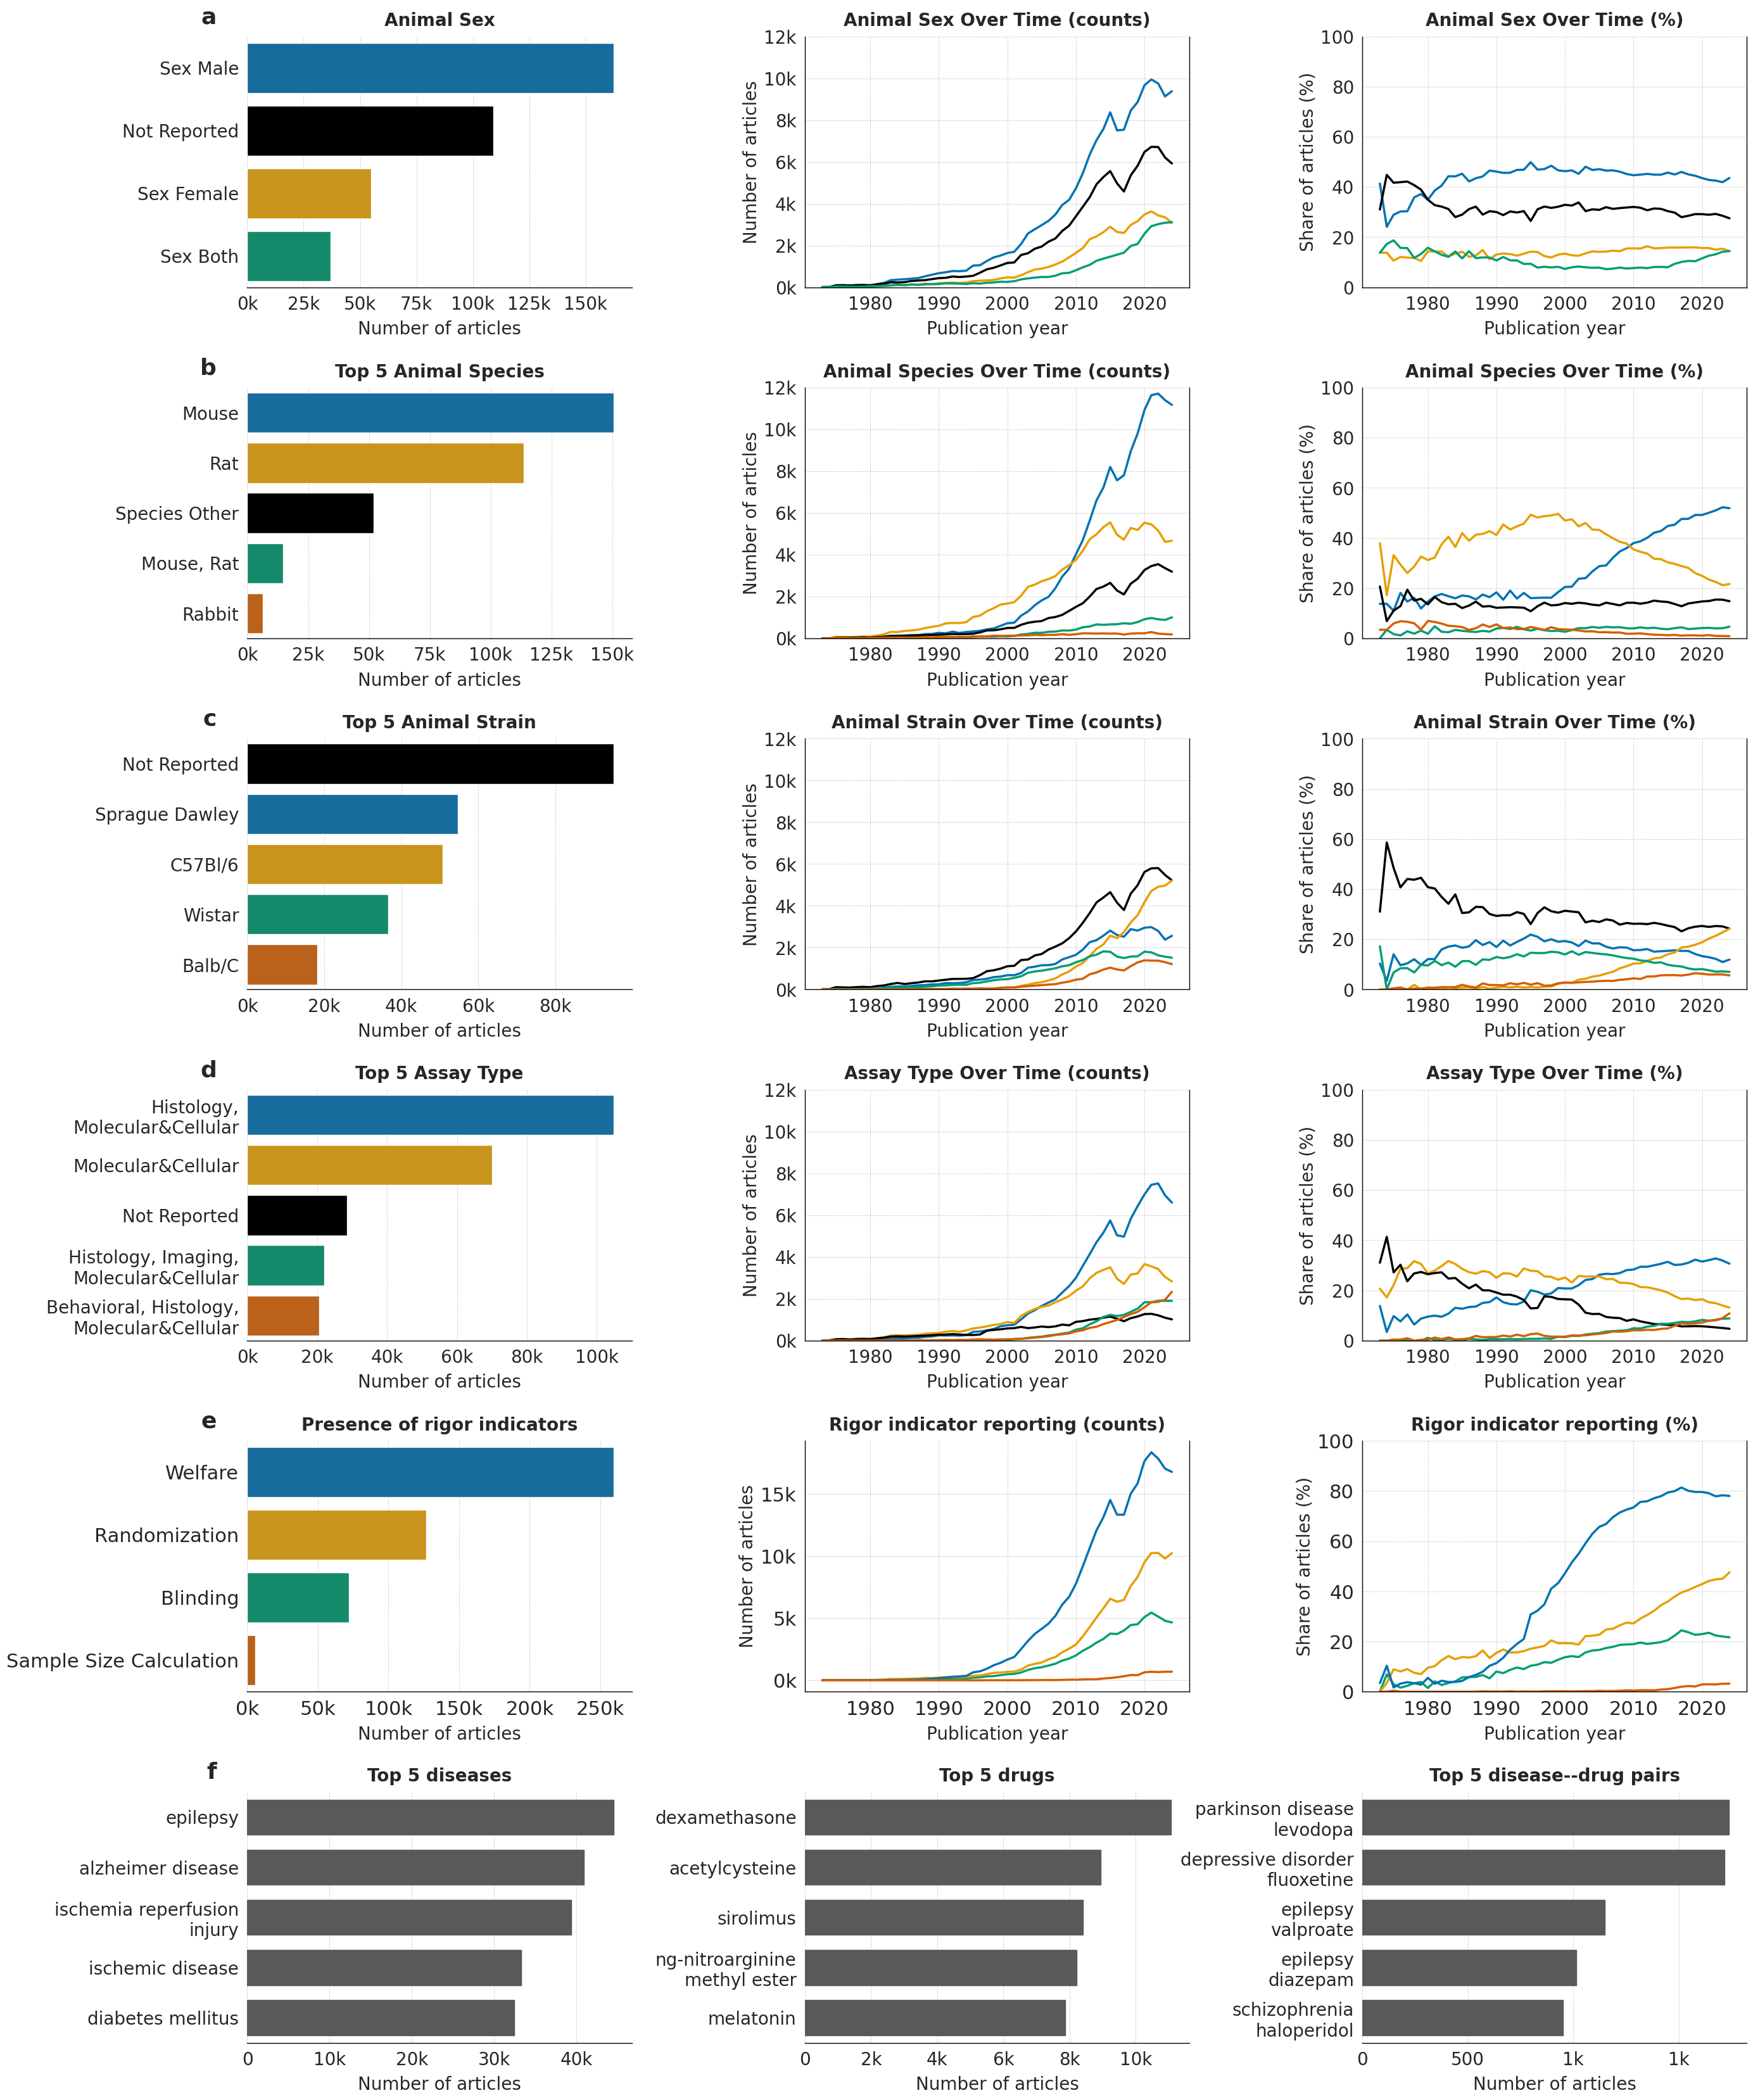

In [143]:
visualize_columns_nature_composite_3col(
    df=dataset_fulltext,
    columns=[
        "animal_sex",
        "animal_species",
        "animal_strain",
        "assay_type",
    ],
    year_col="year",
    top_n=5,
    min_year_count=25,
    exclude_years=[2025],

    # ---- Rigor row ----
    extra_row_columns=[
        "rigor_blinding",
        "rigor_randomization",
        "rigor_welfare",
        "sample_size_calculation",
    ],
    extra_row_values=[
        "blinding-present",
        "randomization-present",
        "welfare-present",
        "sample-size-present",
    ],
    extra_row_title="Rigor indicator reporting",

    # ---- Entity row (NEW) ----
    pairs_df=preclinical_df_to_viz,  # must contain: merged_mondo_label, merged_umls_label, disease<>drug
    add_pairs_row=True,
    pairs_top_n=5,

    save_path="viz/composite_3col_with_rigor_and_entities.pdf",
    show_legend=False,
)

# Metadata


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

def visualize_bars_and_trend(
    df,
    columns,
    year_col="year",
    top_n=10,
    min_year_count=100,
    exclude_years=None,
    save_path=None,
    show_legend=False
):
    """
    Nature-style figure with two bar plots and one trend plot in a single row.

    - First column → independent bar chart.
    - Second column → bar chart (shares colors with trend plot).
    - Third column → trend line plot (% over time).
    - Long category labels automatically wrapped after the 5th word.
    """

    assert len(columns) == 3, "Please provide exactly 3 columns."

    colorblind10 = [
        "#000000", "#009E73", "#CC79A7", "#8B4513",
        "#0072B2", "#E69F00", "#F0E442", "#D55E00",
        "#56B4E9", "#999999"
    ]

    # ---- Style setup ----
    sns.set_theme(style="whitegrid", font_scale=1.4)
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "DejaVu Sans"],
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": "black",
        "axes.linewidth": 1.0,
        "axes.grid": True,
        "grid.linestyle": "--",
        "grid.linewidth": 0.6,
        "axes.labelsize": 22,
        "axes.titlesize": 20,
        "xtick.labelsize": 21,
        "ytick.labelsize": 21,
        "legend.fontsize": 18,
        "legend.title_fontsize": 21,
    })

    # --- Helper: wrap long labels after 5 words ---
    def wrap_label(label, max_words=3):
        if isinstance(label, str):
            words = label.split(" ")
            if len(words) > max_words:
                return " ".join(words[:max_words]) + "\n" + " ".join(words[max_words:])
        return label

    # --- Clean and filter ---
    df[year_col] = pd.to_numeric(df[year_col], errors="coerce")
    if exclude_years is not None:
        df = df[~df[year_col].isin(exclude_years)]

    year_counts = df[year_col].value_counts()
    valid_years = year_counts[year_counts >= min_year_count].index
    df = df[df[year_col].isin(valid_years)]

    total_per_year = df.groupby(year_col).size()

    # Consistent color map for 2nd & 3rd columns
    shared_col = columns[1]
    trend_col = columns[2]

    top_shared_values = df[shared_col].value_counts().head(top_n).index
    consistent_color_map = dict(zip(top_shared_values, colorblind10[:len(top_shared_values)]))

    # --- Setup figure ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={"wspace": 0.35})

    # === BAR 1 (independent colors) ===
    col = columns[0]
    ax = axes[0]
    top_values = df[col].value_counts().head(top_n).sort_values(ascending=False)
    sns.barplot(
        y=[wrap_label(v) for v in top_values.index],  # 🟢 wrapped labels
        x=top_values.values,
        ax=ax,
        palette=colorblind10[:len(top_values)]
    )
    display_col = col.replace("_"," ").title()
    ax.set_title(f"Top {top_n} {display_col}", pad=10, weight="bold")
    ax.set_xlabel("Number of articles")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    sns.despine(ax=ax, left=True)

    # === BAR 2 (shares colors with trend plot) ===
    col = shared_col
    ax = axes[1]
    top_values = df[col].value_counts().head(top_n).sort_values(ascending=False)
    bar_colors = [consistent_color_map.get(v, "#BBBBBB") for v in top_values.index]

    sns.barplot(
        y=[wrap_label(v) for v in top_values.index],  # 🟢 wrapped labels
        x=top_values.values,
        ax=ax,
        palette=bar_colors
    )
    display_col = col.replace("_"," ").title()
    ax.set_title(f"Top {top_n} {display_col}", pad=10, weight="bold")
    ax.set_xlabel("Number of articles")
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))
    sns.despine(ax=ax, left=True)

    # === TREND (3rd col, shares colors with 2nd) ===
    ax = axes[2]
    
    # --- Filter to top categories only ---
    top_cats = top_shared_values
    subset = df[df[trend_col].isin(top_cats)]
    
    # --- Compute total papers per year *within the subset* ---
    year_totals = subset.groupby(year_col).size()
    
    # 🟢 Keep only years with enough papers (within subset)
    valid_years = year_totals[year_totals >= min_year_count].index
    subset = subset[subset[year_col].isin(valid_years)]
    year_totals = year_totals[year_totals.index.isin(valid_years)]
    
    # --- Compute trend data ---
    trend_data = subset.groupby([year_col, trend_col]).size().unstack(fill_value=0)
    trend_data = trend_data[[cat for cat in top_values.index if cat in trend_data.columns]]
    trend_pct = trend_data.div(trend_data.sum(axis=1), axis=0) * 100
    
    # 🟢 Ensure we only plot valid years, sorted chronologically
    trend_pct = trend_pct.loc[sorted(valid_years)]
    year_totals = year_totals.loc[sorted(valid_years)]
    
    # 🟢 Define colors here (AFTER we know trend_pct columns)
    line_colors = [consistent_color_map.get(v, "#BBBBBB") for v in trend_pct.columns]
    
    # --- Plot ---
    trend_pct.plot(ax=ax, linewidth=2.2, color=line_colors, legend=False)

    # Total articles (secondary axis)
    ax_twin = ax.twinx()
    year_totals.plot(   # 🟢 use the filtered subset, not total_per_year
        ax=ax_twin,
        color="#666666",
        linestyle="--",
        linewidth=2,
        alpha=0.7,
        label="Total articles"
    )

    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax_twin.grid(False)
    ax_twin.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

    ax.set_xlabel("Year")
    ax.set_ylabel("% of articles")
    ax_twin.set_ylabel("Total articles")
    display_col = trend_col.replace("_"," ").title()
    ax.set_title(f"{display_col} Over Time", pad=10, weight="bold")

    sns.despine(ax=ax, left=False, right=False)

    # Legend
    if show_legend:
        handles, labels = ax.get_legend_handles_labels()
        handles2, labels2 = ax_twin.get_legend_handles_labels()
        ax.legend(
            handles + handles2,
            labels + labels2,
            bbox_to_anchor=(1.25, 1),  # 🟢 move outside to the right
            loc="upper left",
            frameon=False,
            #title=f"Top {top_n} {trend_col}",
        )

    # --- Final layout ---
    plt.subplots_adjust(left=0.07, right=0.95, top=0.90, bottom=0.10)
    fig.patch.set_facecolor("white")

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300, facecolor="white")

    plt.show()


In [111]:
def make_two_row_three_col_figure(
    df,
    year_col="year",
    exclude_years=None,
    min_year_count=25,
    top_n=5,
    save_path=None,
):
    fig, axes = plt.subplots(2, 3, figsize=(25, 15), gridspec_kw={"wspace": 0.35, "hspace": 0.45})
    df = df[
    df["journal_name"] != "Not Reported"
    ]
    row_specs = [
        ("journal_name", "Top Journals", "Top Journals Over Time (counts)", "Top Journals Over Time (%)"),
        ("first_author_country", "Top First-Author Countries", "Country Over Time (counts)", "Country Over Time (%)"),
    ]

    for row_idx, (col, title_left, title_mid, title_right) in enumerate(row_specs):
        # get top N values for this column
        top_values = (
            df[col]
            .astype(str)
            .value_counts()
            .head(top_n)
            .index
            .tolist()
        )
        print(top_values)

        plot_selected_value_trends_row_3col(
            df,
            ax_bar=axes[row_idx, 0],
            ax_trend_cnt=axes[row_idx, 1],
            ax_trend_pct=axes[row_idx, 2],
            columns=[col] * len(top_values),
            values=top_values,
            year_col=year_col,
            min_year_count=min_year_count,
            exclude_years=exclude_years,
            title_left=title_left,
            title_mid=title_mid,
            title_right=title_right,
            show_legend=False,
        )
        
    left_axes = [axes[i, 0] for i in range(len(row_specs))]
    add_panel_labels_left_column(left_axes, start_letter="a", x_points=-35, y_points=10)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()

In [93]:
dataset_fulltext["journal_name"] = dataset_fulltext["journal_name"].fillna("Not Reported")

In [104]:
dataset_fulltext["first_author_country"] = (
    dataset_fulltext["first_author_country"]
    .replace({
        "Uk": "UK",
        "Usa": "USA"
    })
)

In [94]:
dataset_fulltext[dataset_fulltext["journal_name"]=="Not Reported"]

,PMID,animal_sex,animal_species,rigor_blinding,rigor_randomization,rigor_welfare,assay_type,animal_strain,animal_number,sample_size,...,merged_mondo_label,merged_mondo_termid,merged_umls_label,merged_umls_termid,unique_conditions_linkbert_predictions,unique_interventions_linkbert_predictions,year,journal_name,publication_type,title
254,1008019,Sex Both,"Mouse, Rat",blinding-not-reported,randomization-present,welfare-not-reported,"Behavioral, Physiology","Cf,Sprague Dawley,Swisswebster,Wistar",10.0,sample-size-not-reported,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Reported,NaN,NaN
339,10094188,Not Reported,Species Other,blinding-not-reported,randomization-not-reported,welfare-present,Molecular&Cellular,Not Reported,not reported,sample-size-not-reported,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Reported,NaN,NaN
809,10321575,Not Reported,Mouse,blinding-present,randomization-not-reported,welfare-not-reported,Not Reported,Not Reported,not reported,sample-size-not-reported,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Reported,NaN,NaN
853,10330344,Not Reported,Species Other,blinding-not-reported,randomization-not-reported,welfare-not-reported,Molecular&Cellular,Not Reported,not reported,sample-size-not-reported,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Reported,NaN,NaN
886,10337914,Sex Female,Mouse,blinding-not-reported,randomization-present,welfare-not-reported,"Behavioral, Histology, Molecular&Cellular",Pl,not reported,sample-size-not-reported,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Reported,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371319,9856497,Sex Both,Species Other,blinding-not-reported,randomization-not-reported,welfare-present,"Molecular&Cellular, Physiology",Not Reported,not reported,sample-size-not-reported,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Reported,NaN,NaN
371352,986305,Sex Male,Rat,blinding-not-reported,randomization-present,welfare-present,"Histology, Molecular&Cellular",Sprague Dawley,15.0,sample-size-not-reported,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Reported,NaN,NaN
371428,9871939,Not Reported,"Monkey, Rat",blinding-not-reported,randomization-not-reported,welfare-present,"Molecular&Cellular, Physiology",Not Reported,not reported,sample-size-not-reported,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Reported,NaN,NaN
371576,9889359,Sex Female,Monkey,blinding-not-reported,randomization-not-reported,welfare-present,Molecular&Cellular,Not Reported,9.0,sample-size-not-reported,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Reported,NaN,NaN


['PloS one', 'Scientific reports', 'European journal of pharmacology', 'Brain research', 'International journal of molecular sciences', 'Biochemical and biophysical research communications', 'Neuroscience']
                                               label  count
0                                           Plos One   9965
1                                 Scientific Reports   7245
2                   European Journal Of Pharmacology   6944
3                                     Brain Research   4667
4       International Journal Of\nMolecular Sciences   4030
5  Biochemical And Biophysical\nResearch Communic...   3526
6                                       Neuroscience   3467
['China', 'USA', 'Japan', 'Korea', 'Germany', 'Brazil', 'UK']
     label  count
0    China  90014
1      USA  82373
2    Japan  24933
3    Korea  11965
4  Germany  11560
5   Brazil  10246
6       UK   9615


/tmp/ipykernel_1083241/946617193.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


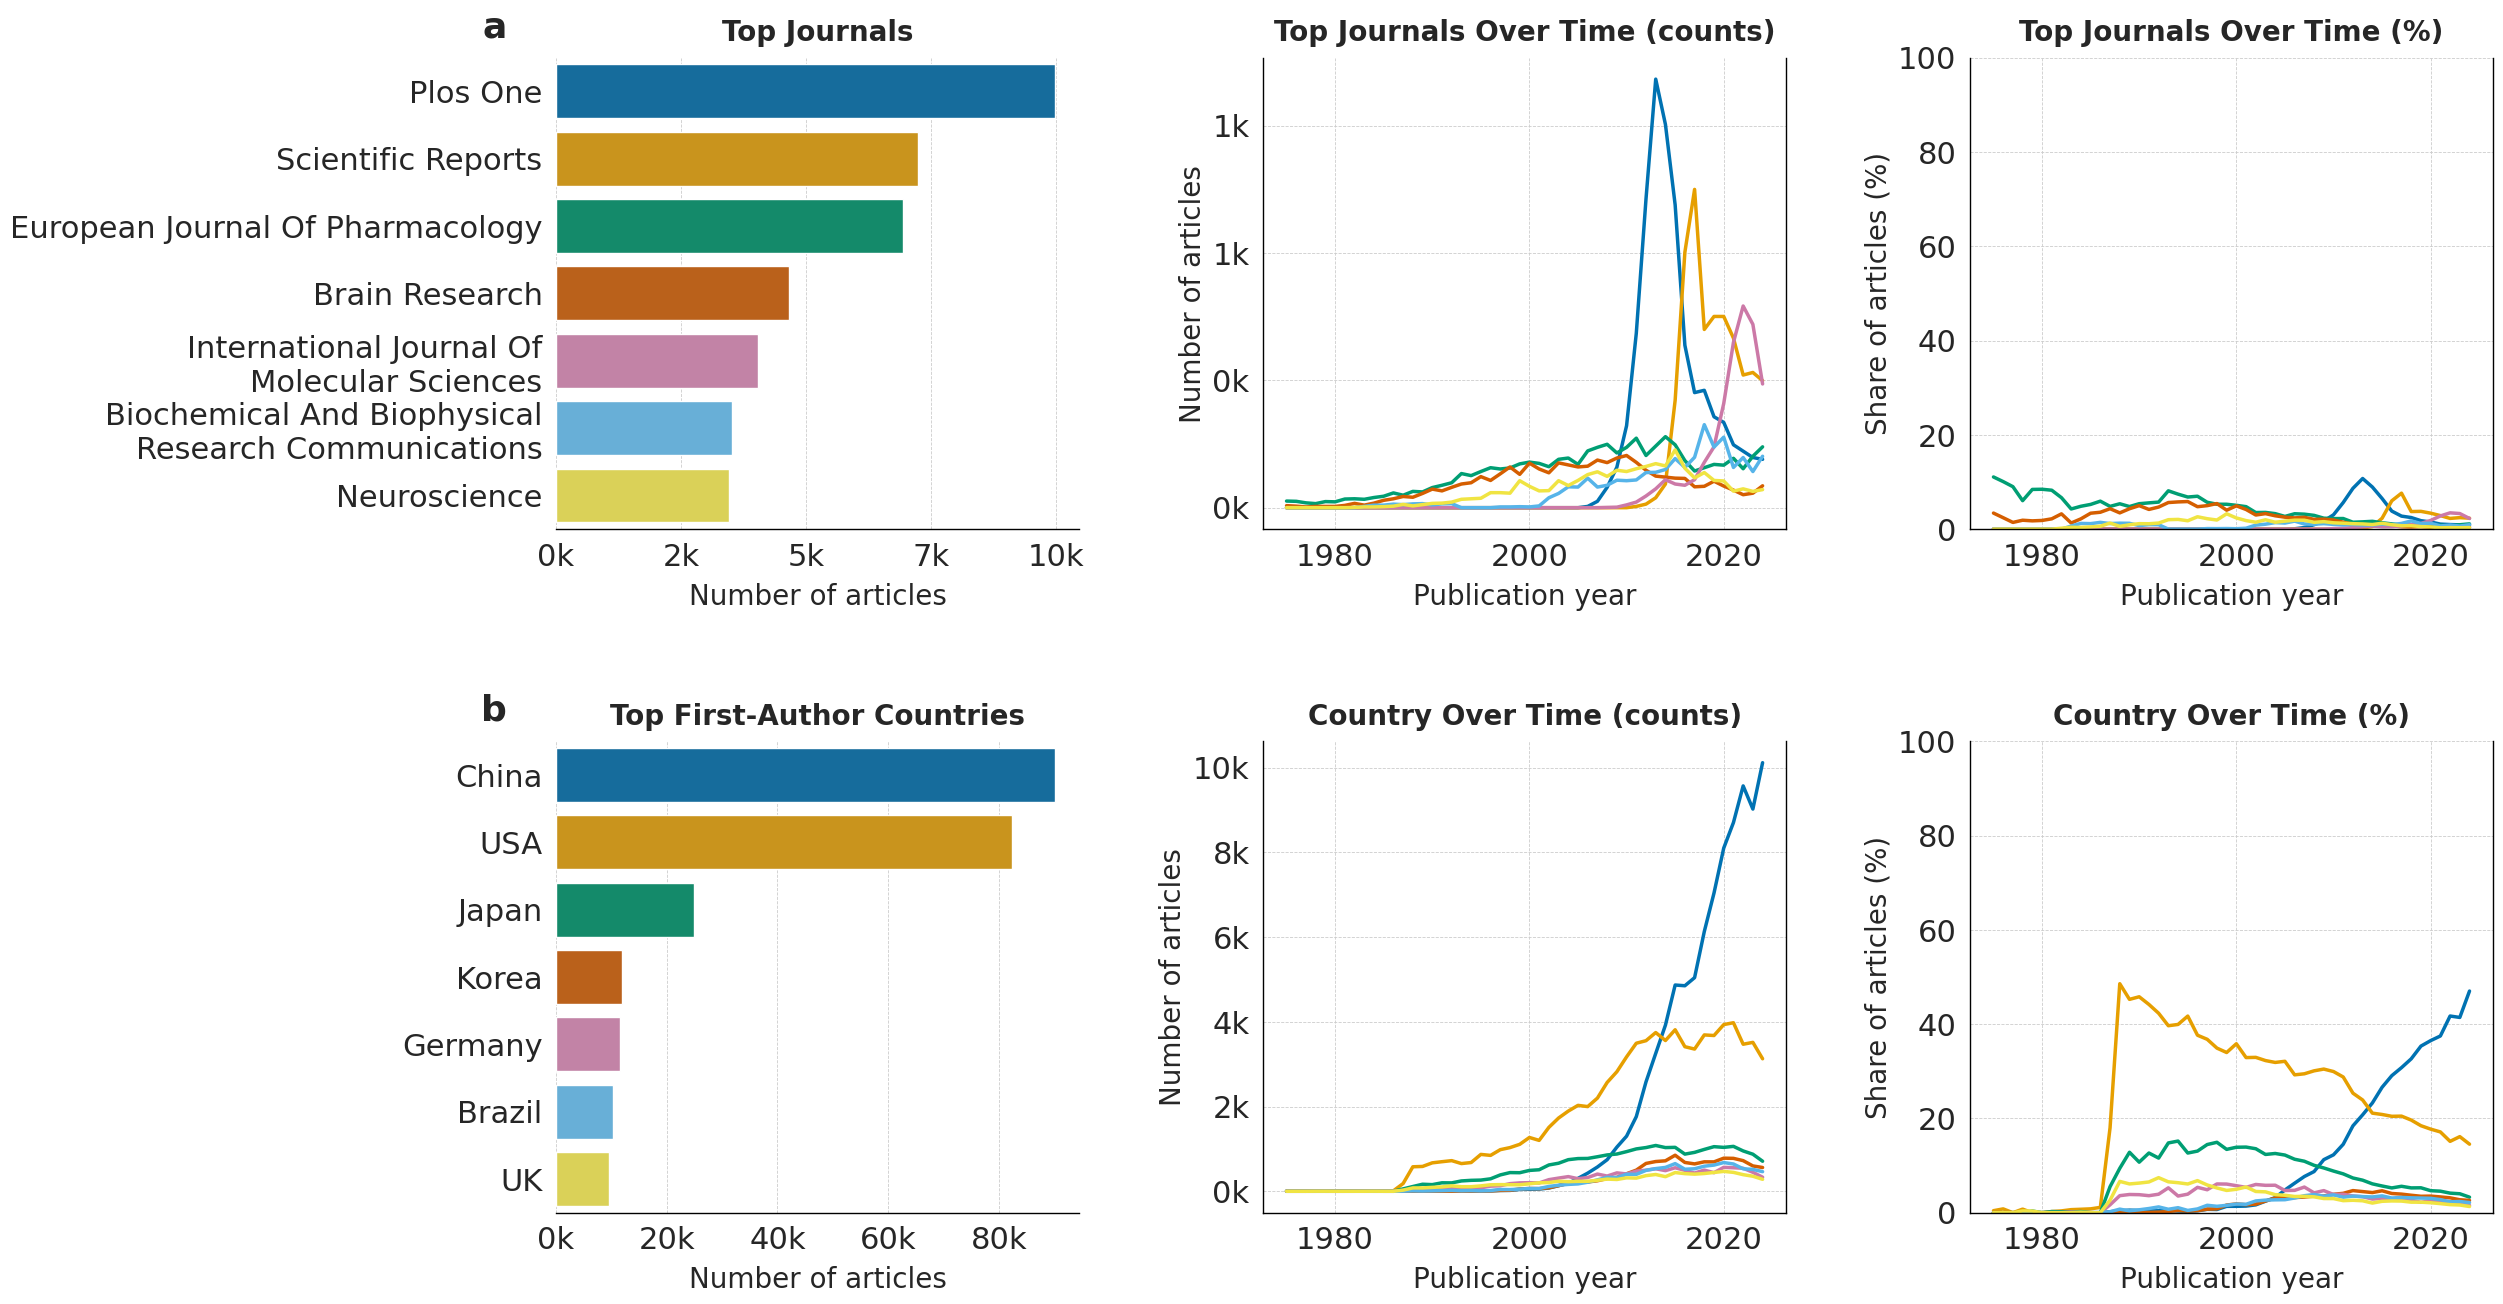

In [116]:
make_two_row_three_col_figure(
    dataset_fulltext,
    year_col="year",
    exclude_years=[2025],
    min_year_count=100,
    top_n=7,
    save_path="viz/animal_studies_journal_country.pdf",
)

/tmp/ipykernel_1083241/4266134132.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1083241/4266134132.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


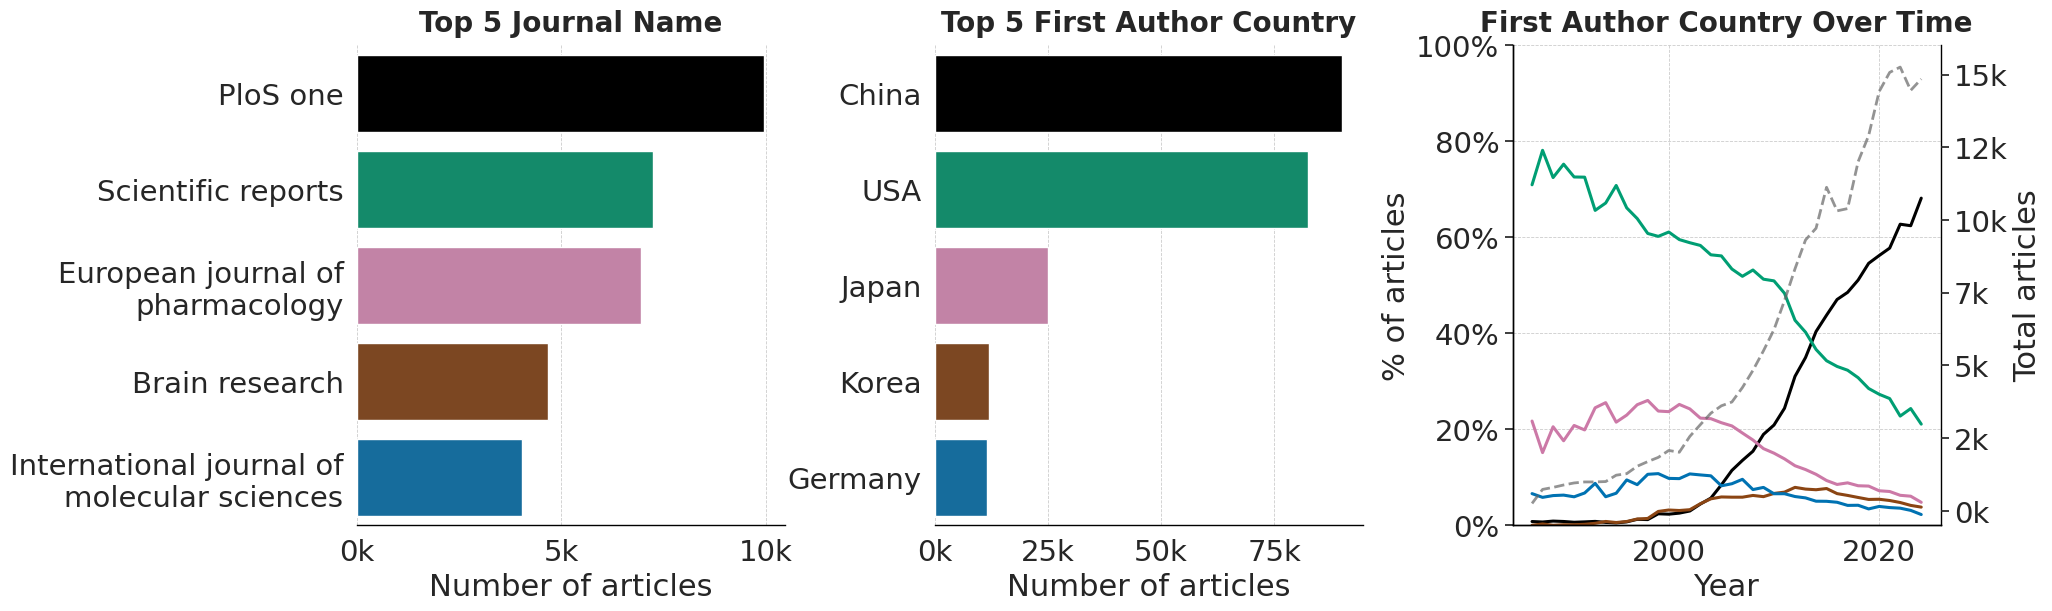

In [46]:
visualize_bars_and_trend(
    dataset_fulltext,
    columns=["journal_name", "first_author_country", "first_author_country"],
    year_col="year",
    exclude_years=[2025],
    top_n=5,
    save_path = "viz/animal_studies_journal_country.pdf"
)

In [171]:
df = dataset_fulltext.copy()
trend_col = "first_author_country"
year_col="year"
top_shared_values = df[trend_col].value_counts().head(10).index
min_year_count = 25

top_cats = top_shared_values
subset = df[df[trend_col].isin(top_cats)]

# --- Compute total papers per year ---
year_totals = subset.groupby(year_col).size()

# 🟢 Keep only years with enough papers
valid_years = year_totals[year_totals >= min_year_count].index
subset = subset[subset[year_col].isin(valid_years)]
year_totals = year_totals[year_totals.index.isin(valid_years)]

# --- Compute trend data ---
trend_data = subset.groupby([year_col, trend_col]).size().unstack(fill_value=0)
trend_pct = trend_data.div(trend_data.sum(axis=1), axis=0) * 100

In [187]:
test_df = dataset_fulltext[['PMID','year','first_author_country']]
test_df[test_df['year']==1980].first_author_country.unique()

array(['unlabeled'], dtype=object)